### Понижение размерности


#### Цель работы

Ознакомиться с основными методами понижения размерности, изучить их применение на практике, сравнить эффективность разных методов и визуализировать результаты.


#### Методические указания

В ходе выполнения этой работы мы познакомимся со разными методами понижения размерности. Эта задача в машинном обучении часто используется для визуализации многомерных данных, снижения объема данных, улучшения качества классификации, устранения мультиколлинеарности признаков. При этом, существуют разные методы понижения размерности, которые отличаются друг от друга не только по внутреннему устройству, но и по "техническим характеристикам", области применения, достоинствам и недостаткам. Поэтому по итогам выполнения данной работы нужно сформировать понимание того, в каких случаях какие методы следует применять.

##### PCA на сгенерированных данных

Самый распространенный метод понижения размерности - метод главных компонент, PCA. Для того, чтобы понять смысл и основной механизм этого метода, мы разберем его действия на нескольких примерах. Для начала - на искусственных данных. Метод главных компонент выделяет самые информативные "направления" в пространстве признаков. Проще всего увидеть это направление на таком датасете, который демонстрирует сильную корреляцию.

Сгенерируем такой набор признаков, для наглядности, двумерный:


In [113]:
import numpy as np
n_samples = 100
x = np.random.normal(0, 1, n_samples)  # Первый признак
y = 2 * x + np.random.normal(0, 0.5, n_samples)  # Второй признак (коррелирован с первым)

X = np.column_stack((x, y))

Можете сами варьировать численные параметры в этой генерации и смотреть, как это влияет на последующие результаты. В нашем случае датасет выглядит так:

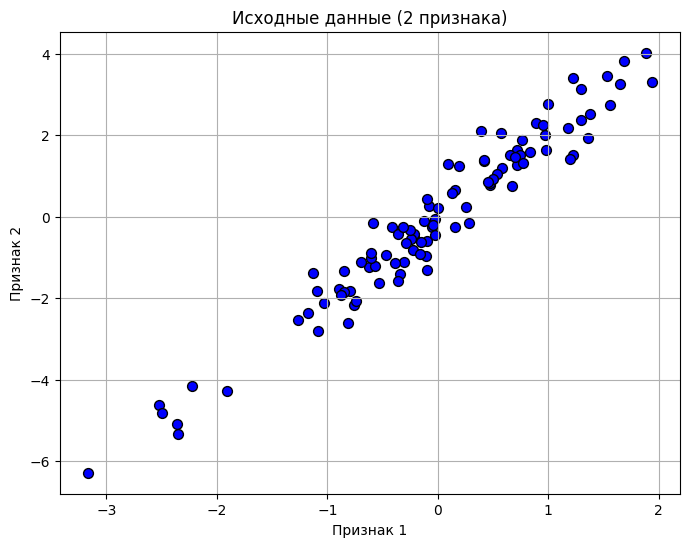

In [114]:
import matplotlib.pyplot as plt

# 2. Создание графика
plt.figure(figsize=(8, 6)) # Устанавливаем размер окна

# Отрисовка точек:
# c='blue' (цвет), edgecolor='black' (обводка), s=50 (размер точки)
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='black', s=50)

# 3. Оформление
plt.title("Исходные данные (2 признака)") # Заголовок
plt.xlabel("Признак 1")                 # Подпись оси X
plt.ylabel("Признак 2")                 # Подпись оси Y
plt.grid(True)                          # Включение сетки

# 4. Показ
plt.show()

Попробуем применить метод понижения размерности сразу, на данных как есть. Для этого импортируем класс данного метода из пакета decomposition:

In [115]:
from sklearn.decomposition import PCA

Теперь мы создаем экземпляр класса. В конструкторе класса указываем количество компонент, которые хотим оставить в данных. Так как у нас всего два измерения, придется оставлять только одно:

In [116]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

У методов понижения размерности интерфейс очень похож на интерфейс методов преобразования данных. Для применения алгоритма вызовем метод fit_transform(). В результате мы получаем одномерный набор данных, который выглядит вот так:

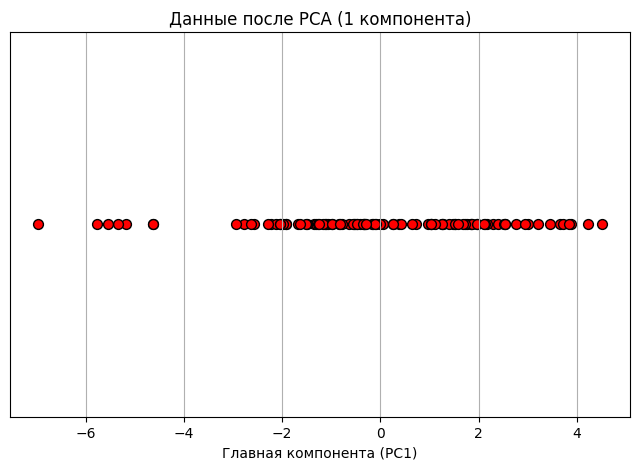

In [117]:
# 2. Создание графика
plt.figure(figsize=(8, 5))

# Отрисовка одномерных данных:
# Чтобы точки легли на одну прямую, по оси Y передаем массив нулей такой же длины
plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='black', s=50)

# 3. Оформление
plt.title("Данные после PCA (1 компонента)")
plt.xlabel("Главная компонента (PC1)")

# Скрываем деления на оси Y, так как они не несут смысла
plt.yticks([])

plt.grid(True, axis='x') # Сетка только по вертикали для наглядности
plt.show()

Это распределение, по сути, представляет собой проекцию исходного множества точек на определенную прямую. Эта прямая представляет собой направление, вдоль которого дисперсия исходного распределения максимальна. Этот вектор (направление) как раз и представляет собой главную компоненту.

Информацию о главной компоненте можно получить в соответствующих свойствах обученного объекта:

In [118]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.42735917 0.90408193]]
Объясненная дисперсия: [0.99151555]


Первое свойство хранит набор векторов главных компонент. Так как в нашем случае мы оставили только одно измерение, и главная компонента тоже будет одна. Это двумерный вектор, который и представляет собой направление в исходном пространстве.

Второй список хранит доли объясненной дисперсии по главным компонентам. Тут у нас опять только одно значение. Оно значит, что понижение размерности с двух до одного измерения сохраняет 98% исходной дисперсии выборки.

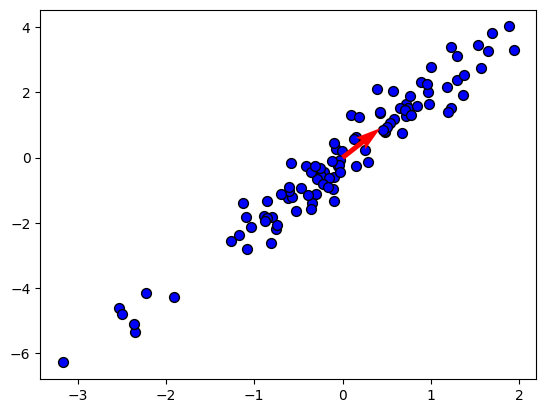

In [119]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

Этот код визуализирует вектор, имеющий начало в начале координат и направление, совпадающее с главной компонентой. Так как исходное распределение также проходит через центр графика, получается очень наглядная картина:

Попробуйте самостоятельно изменить парамеры исходного распределения и посмотреть, как это влияет на направление главной компоненты.

На практике, данные перед применение метода понижения размерности необходимо нормировать. Посмотрим, как нормировка данных влияет на результат. Воспользуемся уже известным методом стандартизации:

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Теперь воспользуемся тем же методом понижения размерности, но уже обучим его на масштабированных данных:

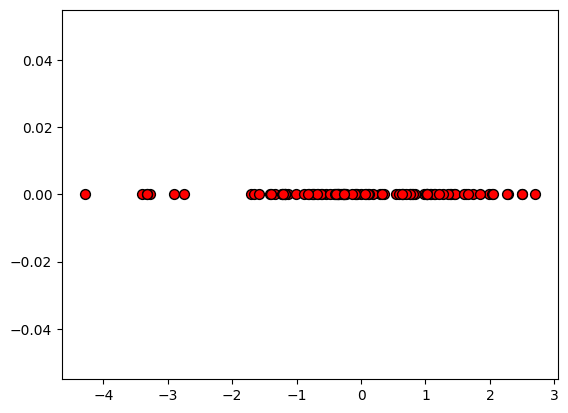

In [121]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

Так как решкалирование в целом сохраняет внутренние структуры, то есть расстояния между точками, это не влияет на результат понижения размерности (за исключением масштаба данных):

##### PCA на многомерных данных

по аналогии проследим работу того же алгоритма, но уже на данных, состоящих из большего количества измерений. Для примера возьмем встроенный датасет о диагностике рака:


In [122]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

Этот набор данных содержит 30 столбцов. Это хорошее число, имеет смысл уменьшить. Пока запомним, что в исходных данных именно 30 столбцов, это пригодится позднее.

Теперь применим метод главных компонент. Сейчас выберем уже две главные компоненты. В таком случае результат можно будет визуализировать. Обратите внимание, что мы обязательно применяем нормализацию:

In [123]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

Исходный датасет мы не могли визуализировать, он тридцатимерный. Но после понижения размерности у нас получился двумерный набор данных. Его вполне можно изобразить на графике:

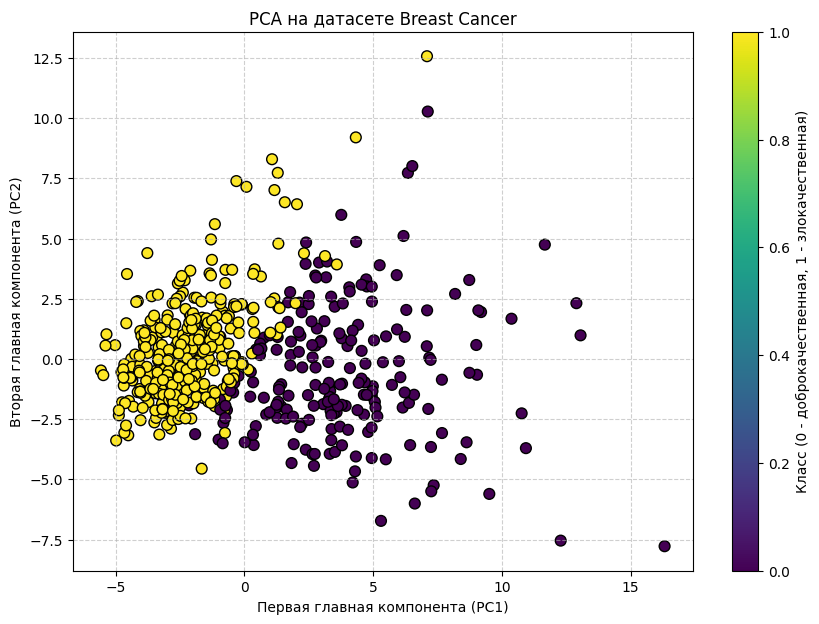

In [124]:
# Настройка размера графика
plt.figure(figsize=(10, 7))

# Отрисовка точек:
# X_pca[:, 0] — первая главная компонента (ось X)
# X_pca[:, 1] — вторая главная компонента (ось Y)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)

# Добавление цветовой шкалы для обозначения классов (0 - доброкачественная, 1 - злокачественная)
plt.colorbar(scatter, label='Класс (0 - доброкачественная, 1 - злокачественная)')

# Подписи осей и заголовок
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('PCA на датасете Breast Cancer')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Если вы задаетесь вопросом, что именно отложено по осям, то ответ может вас разочаровать - главные компоненты. Никакого предметного смысла они не несут.

Мы здесь видим, по сути, проекцию набора точек из тридцатимерного пространства на плоскость. Причем эта плоскость расположена внутри этого тридцатимерного пространства таким образом, чтобы сохранить максимальную дисперсию. Другими словами, эта плоскость расположена так, чтобы в проекции точки были максимально разбросаны.

Можно задаться вопросом, как эта плоскость расположена внутри этого тридцатимерного пространства. Плоскость задается двумя векторами. Именно эти вектора и есть главные компоненты - направления, вдоль которых дисперсия максимальна.

In [125]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Конечно, два тридцатимерных вектора не очень информативны. Но вот они:

В отличие от предыдущего примера, мы все-таки очень сильно сократили размерность. Это значит, что точки все равно сильно сместились относительно своего изначального положения в проекцию. То есть часть данных мы потеряли. Давайте посмотрим, какую именно часть выборочной дисперсии мы сохранили после понижения размерности:

In [126]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


В соответствующем свойстве объекта модели лежит массив, который показывает долю сохраненной (объясненной) дисперсии данных по каждой компоненте. Здесь мы видим, что проекция на первую главную компоненту сохраняет 44% дисперсии исходных данных. Это значит, что если бы мы сократили размерность до одной, то потеряли бы 56% исходной информации.

Введение второй компоненты добавляет еще 19% дисперсии. Таким образом, всего у нас получается 63%. Можно считать, что понижение размерности в данном случае приводит к потере 37% информации о разбросе точек, имеющейся в исходном наборе.


##### Метод локтя для PCA

Метод понижения размерности полезен для визуализации данных, но применяют его не только для этого. Он может быть хорошим помощником в тех случаях, когда в исходных данных слишком много признаков, их число надо сократить, но так, чтобы максимально сохранить имеющуюся информацию. В таком случае встает вопрос выбора количества компонент.

При определении оптимального количества компонент следует ориентироваться на то, насколько быстро растет количество информации в зависимости от количества измерений. Для того, чтобы отследить эту зависимость, построим график. Для этого построим алгоритм главных компонент с количеством компонент от 1 до 30:


In [127]:
n_components_range = range(1, 31)
explained_variance = []

Для каждого количества обучим и оценим соответствующую модель и запомним процент объясненной дисперсии:

In [128]:
for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

Мы получаем такую характерную картину:

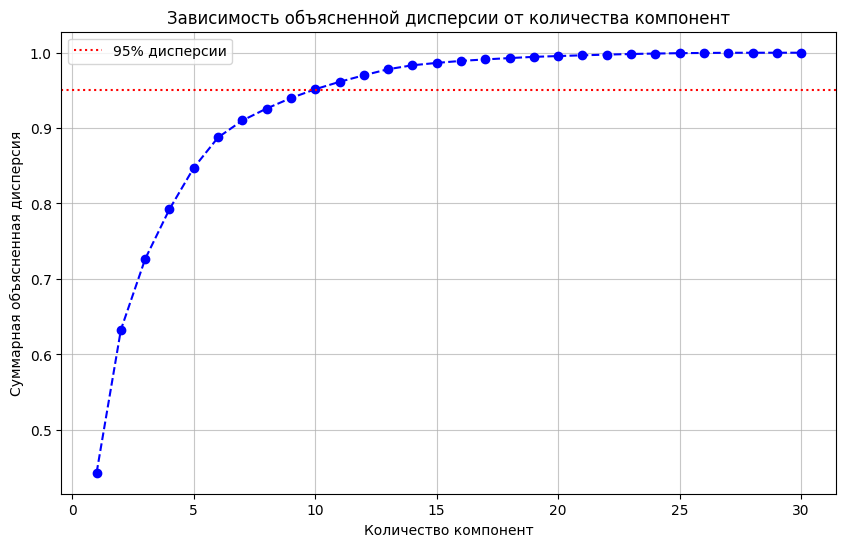

In [129]:
# Настройка размера графика
plt.figure(figsize=(10, 6))

# Отрисовка графика: синяя пунктирная линия с круглыми маркерами
plt.plot(n_components_range, explained_variance, marker='o', linestyle='--', color='b')

# Заголовок и подписи осей
plt.title('Зависимость объясненной дисперсии от количества компонент')
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объясненная дисперсия')

# Настройка сетки для удобства чтения
plt.grid(True, linestyle='-', alpha=0.7)

# Добавление горизонтальной линии на уровне 95% для наглядности (опционально)
plt.axhline(y=0.95, color='r', linestyle=':', label='95% дисперсии')
plt.legend()

plt.show()

Единственная главная компонента обеспечивает 44% вариации исходных данных (мы уже видели это число ранее). При добавлении второй - мы получаем значительную прибавку. При добавлении третьей - прибавка чуть меньше. С каждой новой компонентой мы получаем чуть меньше дополнительной информации.

Смысл в том, чтобы найти такое количество, которое дает оптимальное количество сохраненной информации. Для этого найдем такое значение, в котором данная кривая максимально изгибается. Это и будет локоть. Можно предположить, что в данном случае оптимальное количество 6 или 7 компонент. Если брать больше, дополнительные измерения уже не обеспечат такого значительного прироста информации.

In [130]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")


Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


При выводе массива значений объясненной дисперсии мы видим два уже знакомых нам значения, а числа дальше показывают, сколько дополнительной объясненной дисперсии прибавляет каждая следующая главная компонента:

Обратите внимание, что в данном методе первые компоненты не зависят от того, сколько компонент мы задала. Другими словами, метод всегда найдет одну и ту же главную компоненту, ее положение не зависит от количества компонент, которые мы оставляем. То есть, задание количества компонент по сути является лишь критерием остановки алгоритма (как ограничение глубины решающего дерева).

Именно поэтому если мы построим две первые главные компоненты этой семимерной модели, они будут полностью идентичны предыдущей модели:

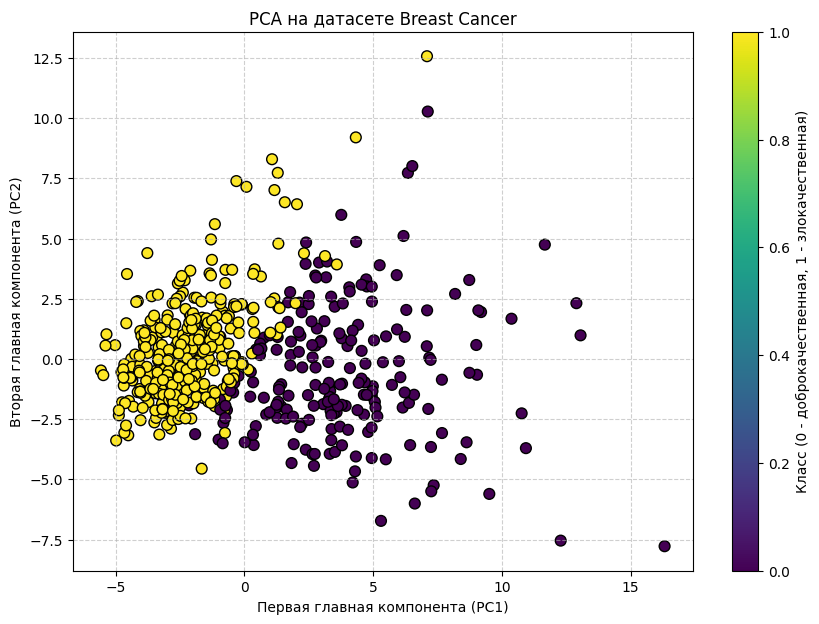

In [131]:
# Настройка размера графика
plt.figure(figsize=(10, 7))

# Отрисовка точек:
# X_pca[:, 0] — первая главная компонента (ось X)
# X_pca[:, 1] — вторая главная компонента (ось Y)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)

# Добавление цветовой шкалы для обозначения классов (0 - доброкачественная, 1 - злокачественная)
plt.colorbar(scatter, label='Класс (0 - доброкачественная, 1 - злокачественная)')

# Подписи осей и заголовок
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('PCA на датасете Breast Cancer')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Это, в частности значит, что для выбора количества компонент методом локтя необязательно было обучать тридцать моделей подряд. Попробуйте самостоятельно достичь того же результата, но гораздо более рациональным способом.

##### Метод LDA

Метод главных компонент неплохо работает в большинстве случаев. Однако, у него есть один недостаток - он принимает во внимание только взаимное расположение точек. Если перед вами датасет для классификации, этот метод может найти такие компоненты, то есть такие направления в исходном пространстве, после проекции на которые, точки разных классов могут оказаться еще ближе друг к другу, чем были в исходном распределении. Это может сильно осложнить задачу классификации, когда после проекции точки классов перемешаются.

Именно для решения этой проблемы существует метод линейного дискриминантного анализа. Он принимает во внимание значение целевой переменной. И выбирает направления проекции таким образом, чтобы максимизировать расстояние между классами. Рассмотрим, например, такой датасет:


In [132]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

Это двумерный набор искусственных данных для классификации. Вот как он выглядит вместе с информацией о классах:

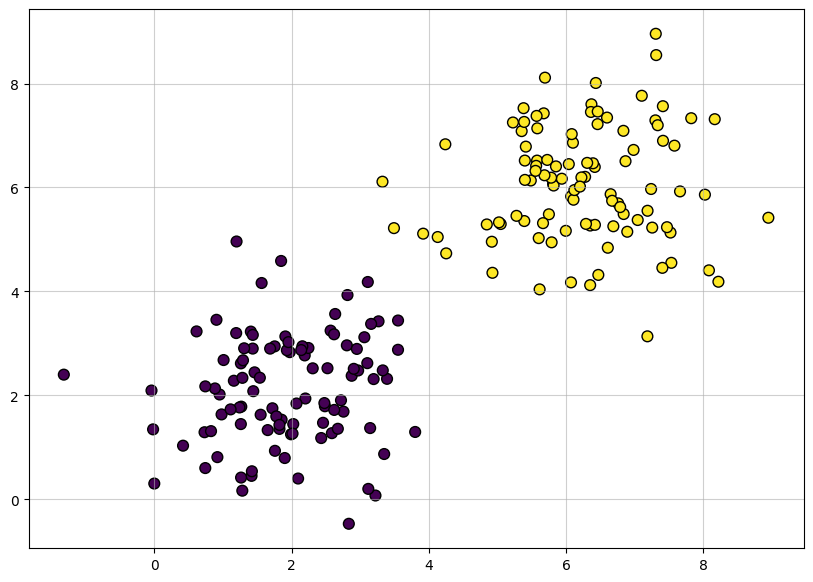

In [133]:
# Настройка размера графика
plt.figure(figsize=(10, 7))

# Отрисовка точек:
# X_pca[:, 0] — первая главная компонента (ось X)
# X_pca[:, 1] — вторая главная компонента (ось Y)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)

plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

Легко представить себе, что проецируя это распределение вдоль некоторых направлений, изначально очень разделимые классы могут полностью перемешаться. Посмотрим, как этому препятствует метод LDA. Интерфейс у класса этого метода, конечно, точно такой же, как и у предыдущего:

In [134]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

На рисунке в проекции это выглядит так (обратите внимание, что классы остались линейно разделимыми):

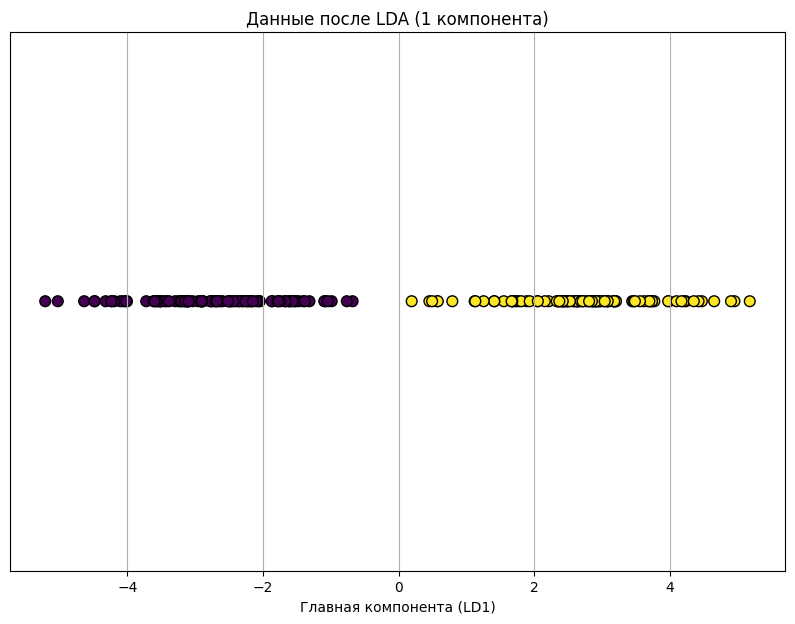

In [135]:
# Настройка размера
plt.figure(figsize=(10, 7))

# Отрисовка проекции
# X_lda — одномерный массив, np.zeros_like создаёт массив нулей такой же длины для оси Y
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolor='k', s=60)

# Оформление
plt.title('Данные после LDA (1 компонента)')
plt.xlabel('Главная компонента (LD1)')
plt.yticks([]) # Убираем деления по оси Y, так как они не несут смысла
plt.grid(True)

plt.show()

Как и в предыдущем методе, мы можем найти информацию о направлении проекции в исходном пространстве. Для этого в методе LDA есть свойство intercept:

In [136]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[9.74244303 6.88903428]]


В данном случае, это свойство содержит один двумерный вектор:

Именно его можно использовать для визуализации направления проекции:

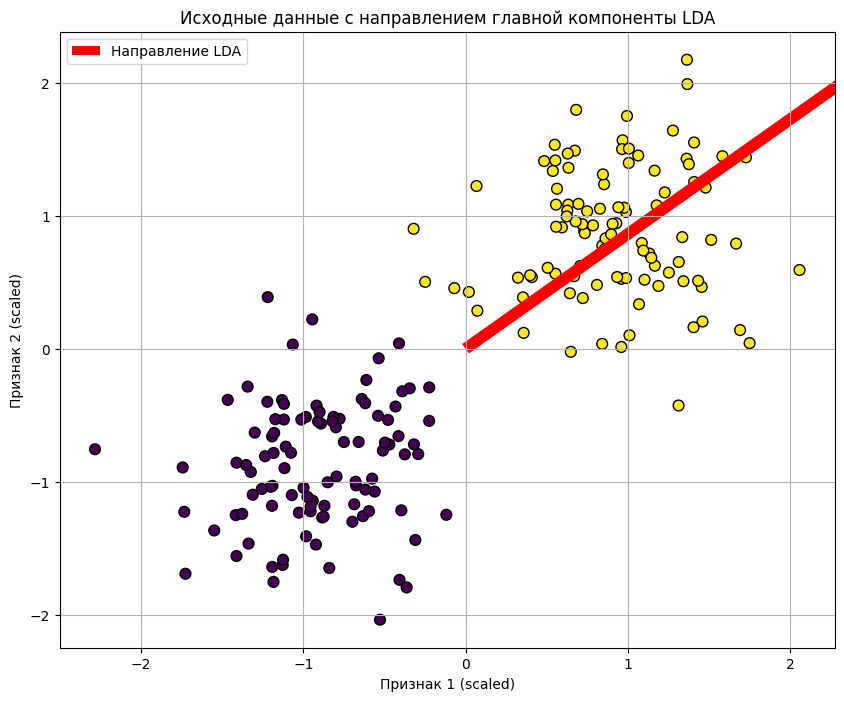

In [137]:
# 1. Центрируем вектор для визуализации (находим среднее по признакам)
mean_x = X_scaled[:, 0].mean()
mean_y = X_scaled[:, 1].mean()

# 2. Получаем вектор направления из коэффициентов LDA
direction = lda.coef_[0]

# 3. Настройка графика
plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)

# 4. Отрисовка вектора (умножаем на масштаб для наглядности)
# Параметры quiver: начало (x, y), направление (u, v)
plt.quiver(mean_x, mean_y, direction[0], direction[1],
           color='red', scale=5, width=0.015, label='Направление LDA')

plt.title('Исходные данные с направлением главной компоненты LDA')
plt.xlabel('Признак 1 (scaled)')
plt.ylabel('Признак 2 (scaled)')
plt.grid(True)
plt.legend()
plt.show()

##### Метод LDA для анизатропных классов

В примере выше вы можете самостоятельно сравнить результаты работы метода LDA и метода главных компонент. В данном случае они дадут очень схожие результаты. Но в ряде случаем можно наглядно показать, чем они отличаются. Рассмотри такой датасет:


In [138]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

In [139]:
# 2. Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA (2 компоненты для визуализации, можно и 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. LDA (1 компонента для проекции)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

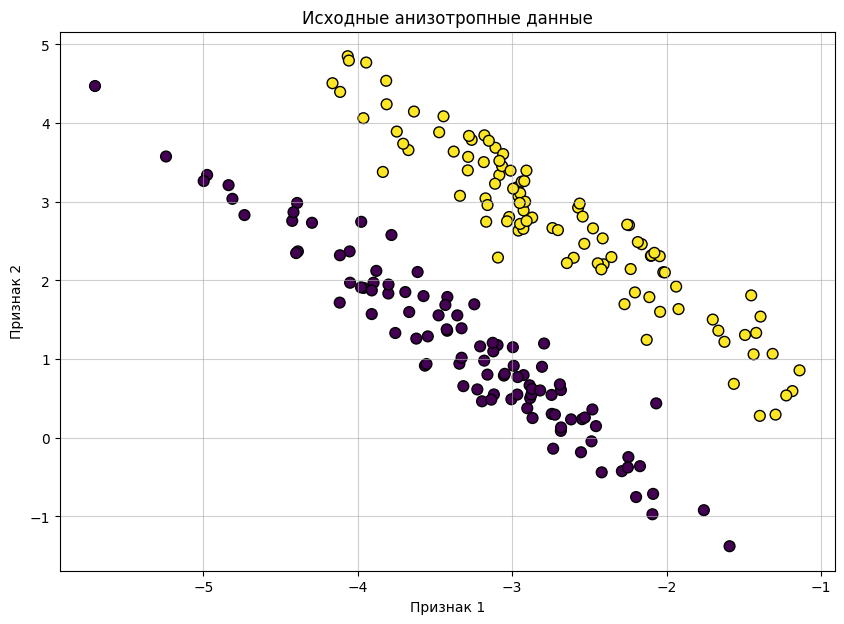

In [140]:
# 5. Исходные данные (не стандартизованные) с цветом по классам
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Исходные анизотропные данные')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, linestyle='-', alpha=0.6)
plt.show()

Вот как выглядят эти данные:

Легко заметить, что направление максимальной дисперсии в данном случае приведет к полному перемешиванию классов в данной выборке. Мы увидим это на практике в сравнении двух методов.

Сперва обучим метод линейного дискриминантного анализа на этих данных. Вот как выглядит результат понижения размерности:

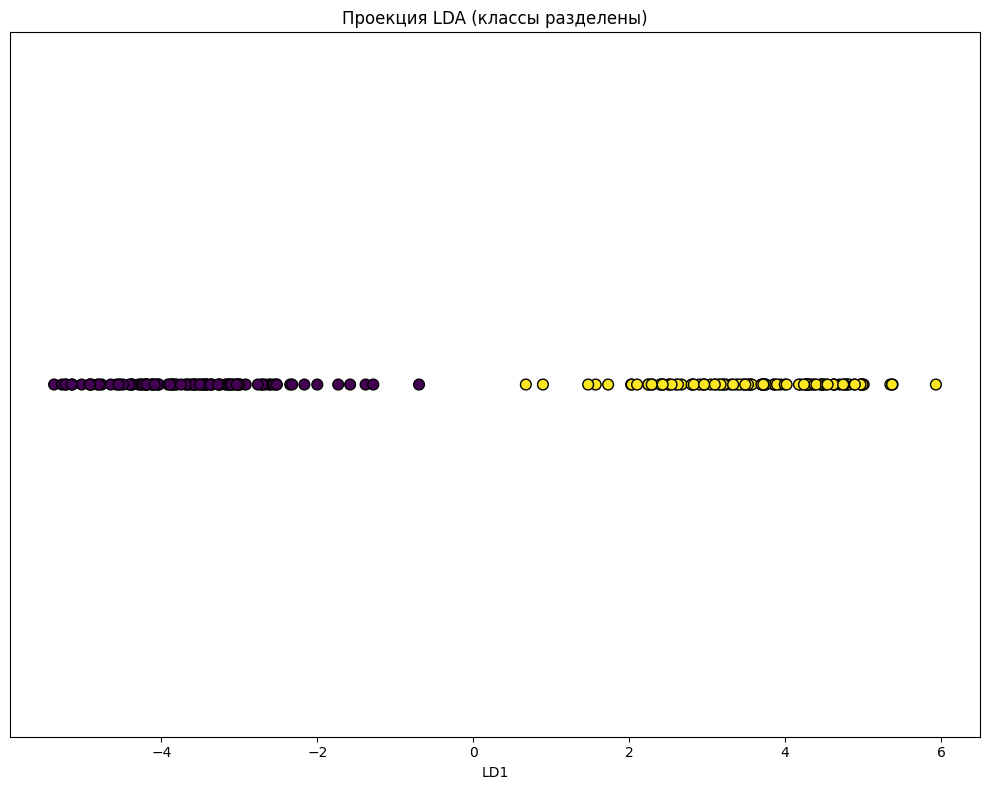

In [141]:
# 7. Сравнение одномерных проекций LDA и PCA (подграфики)
plt.subplots(figsize=(10, 8))

# LDA
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Проекция LDA (классы разделены)')
plt.yticks([])
plt.xlabel('LD1')


plt.tight_layout()
plt.show()

Классы остались разделимыми. Более наглядно можно увидеть, как именно произошла проекция в исходном пространстве:

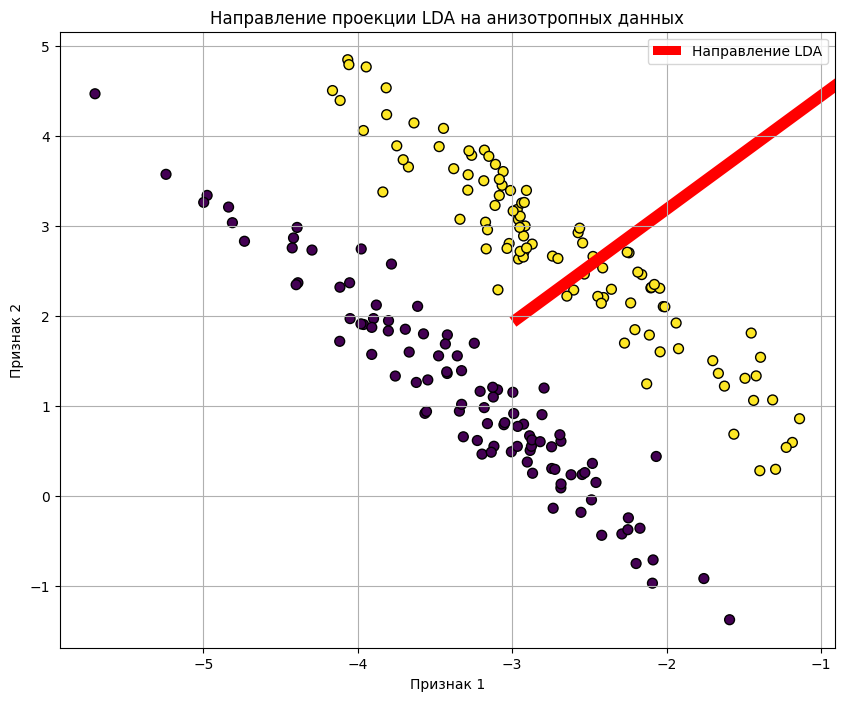

In [142]:
# 8. Визуализация направления LDA на исходных данных
direction = lda.coef_[0]
# Направление в исходном пространстве (обратное масштабирование через scaler)
direction_original = direction / scaler.scale_  # приблизительная коррекция, можно и просто direction

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
# Центр стрелки возьмём среднюю точку данных
center_x, center_y = X[:, 0].mean(), X[:, 1].mean()
plt.quiver(center_x, center_y, direction_original[0], direction_original[1],
           color='red', scale=3, width=0.015, label='Направление LDA')
plt.title('Направление проекции LDA на анизотропных данных')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True)
plt.show()

Алгоритм выбрал именно то направление, которое сохраняет разделимость классов. Примечательно то, что метод главных компонент не принимает во внимание значение целевой переменной и, как следствие, приводит к совершенно другой проекции. Вот как выглядит прямая, на которую осуществляется проецирование в методе главных компонент:

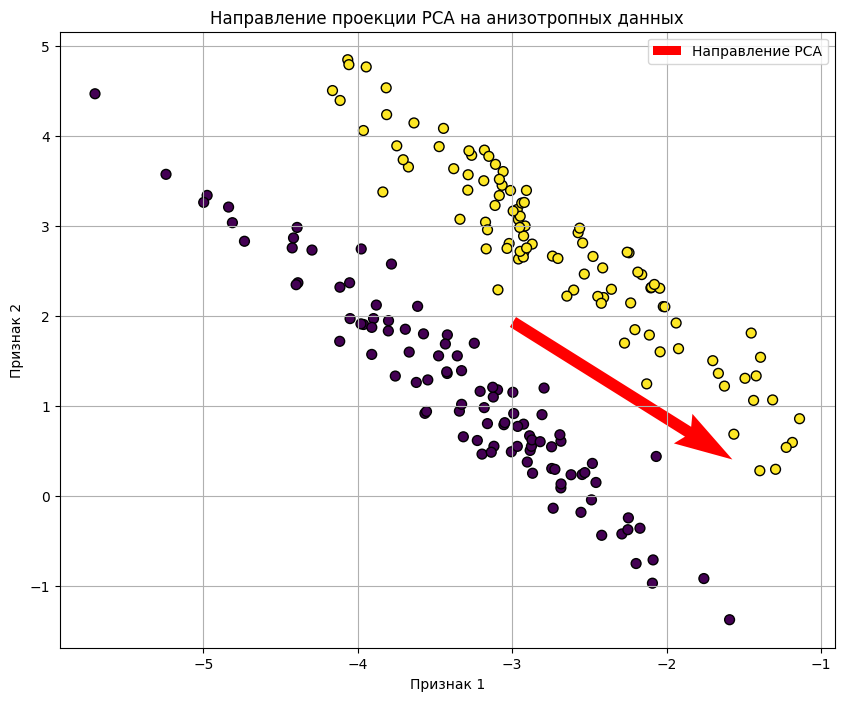

In [143]:
# 9. Дополнительно: направление PCA (направление максимальной дисперсии)
pca_dir = pca.components_[0]
# преобразуем в исходный масштаб примерно
pca_dir_original = pca_dir / scaler.scale_
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.quiver(center_x, center_y, pca_dir_original[0], pca_dir_original[1],
           color='red', scale=3, width=0.015, label='Направление PCA')
plt.title('Направление проекции PCA на анизотропных данных')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True)
plt.show()

Соответственно, после проекции датасет выглядит так:

Text(0.5, 0, 'PC1')

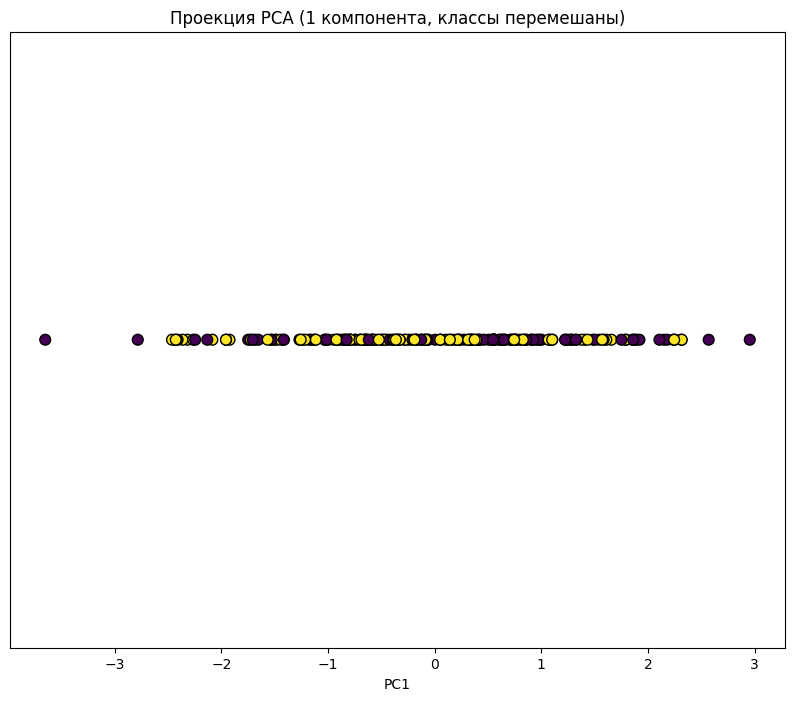

In [144]:
# PCA (первая главная компонента)
plt.subplots(figsize=(10, 8))

X_pca_1d = pca.transform(X_scaled)[:, 0]  # первая главная компонента (одномерная)
plt.scatter(X_pca_1d, np.zeros_like(X_pca_1d), c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Проекция PCA (1 компонента, классы перемешаны)')
plt.yticks([])
plt.xlabel('PC1')


Понижение размерности методом главных компонент, несомненно, сохраняет гарантированно больше информации от исходного распределения. Но если применять его в качестве предварительного этапа обработки данных перед классификацией, то пользы от метода линейного дискриминантного анализа может быть значительно больше.

##### Метод t-SNE

Рассмотрим еще один интересный метод понижения размерности - t-SNE. Он часто используется для визуализации кластеров - то есть близких групп точек в наборе данных. Давайте рассмотрим механизм его действия на примере уже использованного нами датасета для классификации:


Для обучения метода, как всегда импортируем соответствующий класс. Его интерфейс не отличается от других классов, реализующих алгоритмы обучения без учителя:

In [145]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

Результат работы тоже не удивляет своей оригинальностью. Мы видим два различных кластера точек, которые соответствуют двум исходным классам в датасете:

Text(0.5, 0, 'PC1')

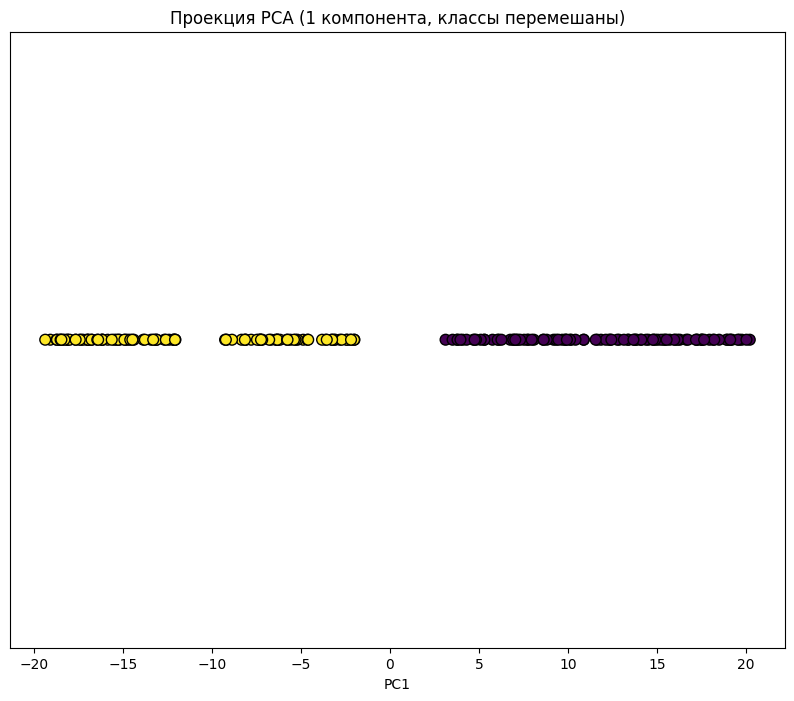

In [146]:

plt.subplots(figsize=(10, 8))

plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=60)
plt.title('Проекция PCA (1 компонента, классы перемешаны)')
plt.yticks([])
plt.xlabel('PC1')


Однако, имейте в виду, что данному алгоритму нигде не передавались метки классов, то есть значение целевой переменной. Алгоритм выделил эти группы точек самостоятельно, ориентируясь исключительно на их схожесть.

Самостоятельно проверьте работу этого алгоритма на созданном в предыдущем пункте анизотропном датасете.

Алгоритм t-SNE является параметрическим. У него есть один главный гиперпараметр, который существенно влияет на работу алгоритма. Это так называемый perplexity - он влиет на то, какие структуры будут превалировать в анализе, крупномасштабные или мелкие.

Теоретически очень сложно прочувствовать влияние этого параметр на суть работы алгоритма. Поэтому мы попробуем разные значения на практике. Авторы алгоритма рекомендуют в качестве рабочего диапазона значений этого параметра разброс от 5 до 50. Попробуем несколько конкретных значений из этого диапазона:

Теперь обучим для каждого значения соответствующий алгоритм и визуализируем его результаты:

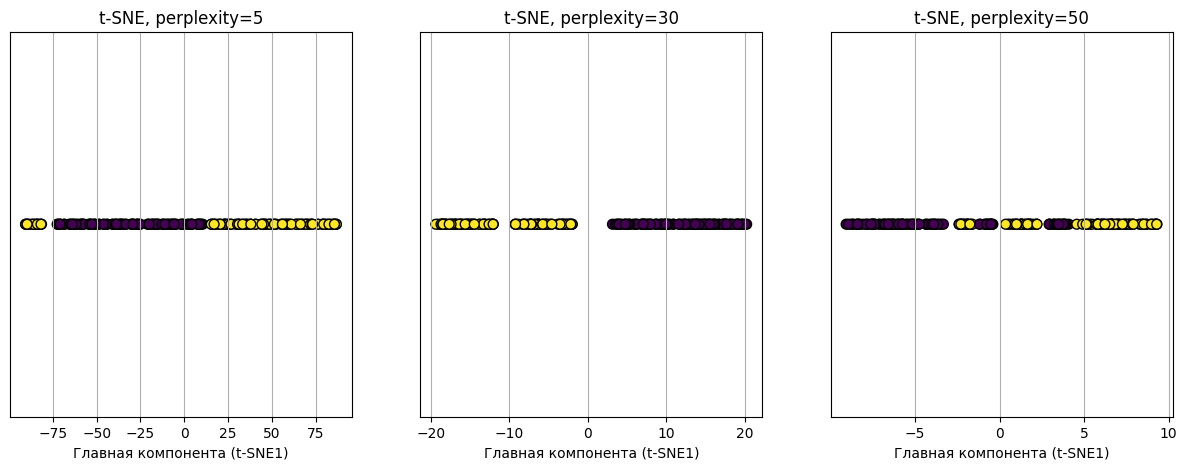

In [147]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))
for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)

Конечно, в таком одномерном варианте сложно оценить формирование структур в данных. Поэтому самостоятельно проверьте работу этого алгоритма на более многомерных данных.

##### Kernel PCA для нелинейных данных

Из рассмотренных выше моделей только t-SNE является нелинейным. Два предыдущие методы осуществляют только линейные преобразования исходного пространства. Однако, для некоторых методов возможно применение трюка с ядерными функциями, то есть введение нелинейного преобразования.

Давайте посмотрим датасет с линейно неразделимыми классами:


In [148]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

# 2. Стандартизация (важна для корректной работы ядерных функций)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Это довольно часто используемый искусственный датасет с ярко выраженной нелинейностью:

/tmp/ipykernel_11583/3238980215.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


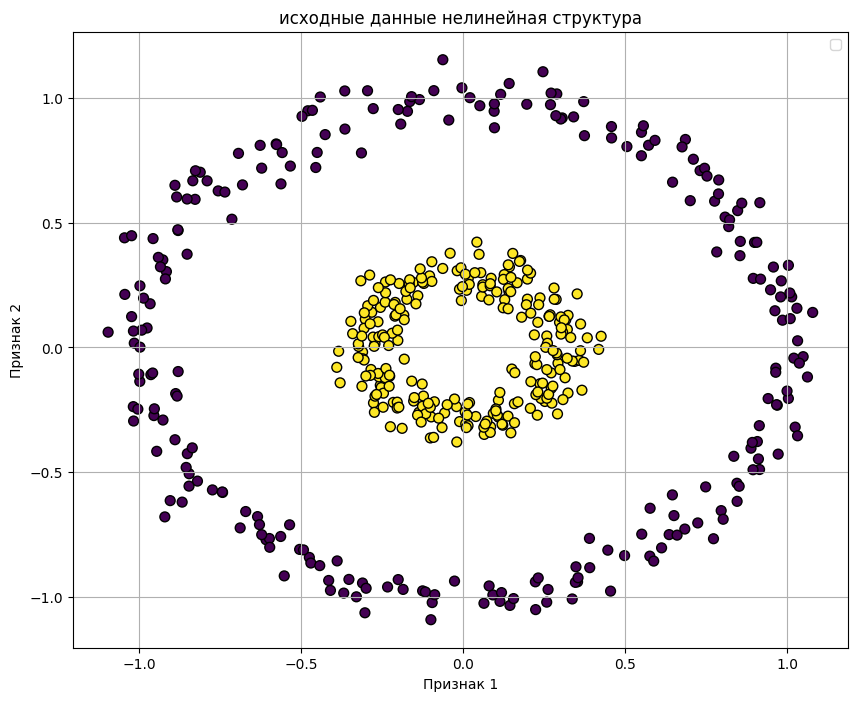

In [149]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)

plt.title('исходные данные нелинейная структура')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True)
plt.show()

Ядерные функции работают в методе главных компонент примерно также, как и в методе опорных векторов. И ядерные функции используются такие же. Мы попробуем три самые распространенные:

In [150]:
kernels = ['linear', 'poly', 'rbf']


Теперь для каждой функции ядра обучим соответствующий алгоритм и визуализируем результаты. Для разнообразия мы "понизим" размерность с двух до двух. Сейчас это имеет смысл, так как имеет место сложное нелинейное преобразование, так что после него мы явно увидим действие той или иной ядерной функции:

In [151]:

kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
X_kpca = kpca.fit_transform(X_scaled)

Вот так выглядит итоговое преобразование по использованным функциям:

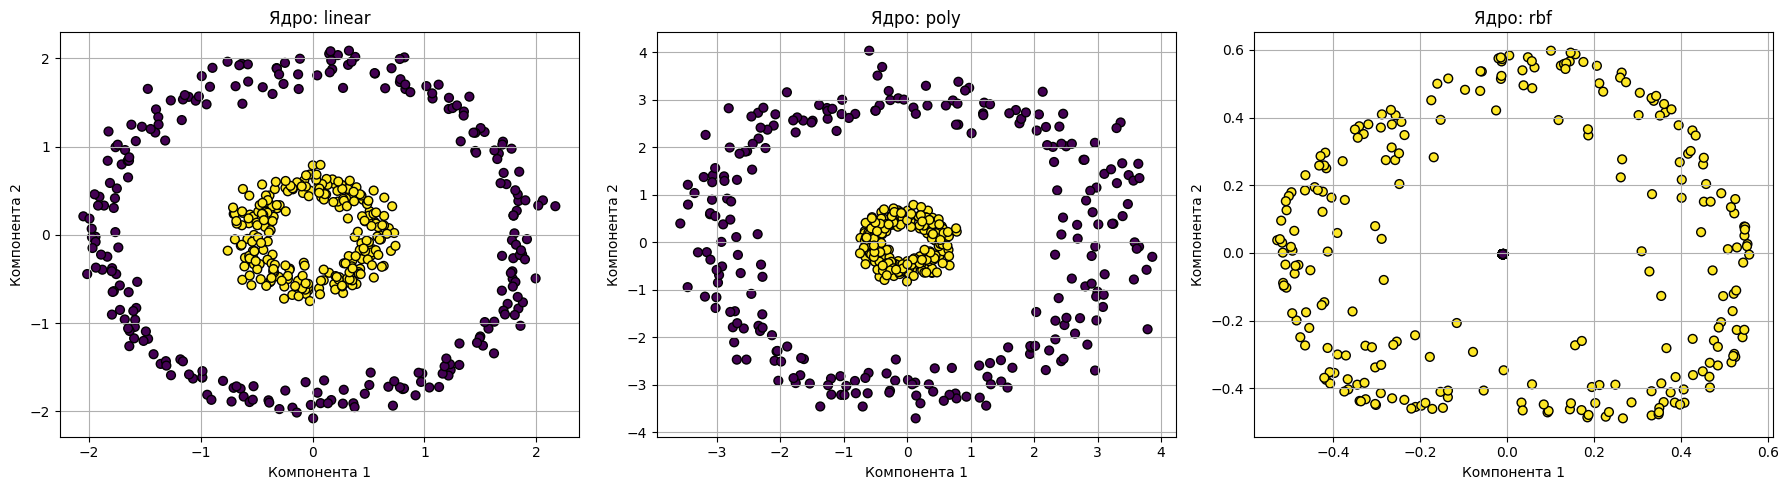

In [153]:
# 3. Явно создаем фигуру и оси
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4. Проходим циклом по индексам, чтобы не было проблем с итерацией
for i, kernel in enumerate(kernels):
    # Обучаем модель
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X_scaled)

    # Рисуем на конкретной оси
    axes[i].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
    axes[i].set_title(f'Ядро: {kernel}')
    axes[i].set_xlabel('Компонента 1')
    axes[i].set_ylabel('Компонента 2')
    axes[i].grid(True)

# 5. Принудительно выводим
plt.tight_layout()
plt.show()

Кроме применения разных функций, можно вспомнить, что радиально-базисная ядерная функция параметризуется степенью гамма. Точно также эмпирически можно проверить разные значения этого гиперпараметра:

In [154]:
gamma_values = [0.1, 1, 10]

Вот как выглядят получившиеся распределения:

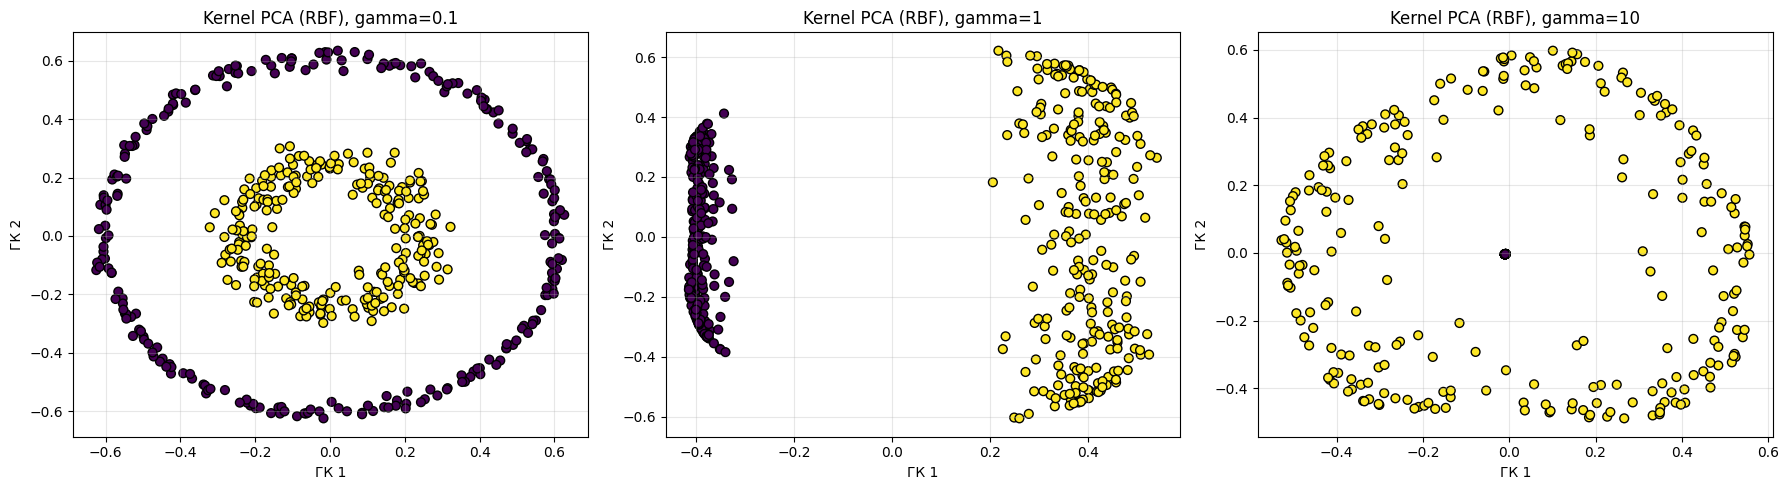

In [156]:
# 3. Создаем сетку графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, g in enumerate(gamma_values):
    # Обучаем KernelPCA только с ядром RBF, меняя gamma
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=g)
    X_kpca = kpca.fit_transform(X_scaled)

    # Отрисовка
    axes[i].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
    axes[i].set_title(f'Kernel PCA (RBF), gamma={g}')
    axes[i].set_xlabel('ГК 1')
    axes[i].set_ylabel('ГК 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Задания для самостоятельного выполнения

1. Попробуйте изменить уровень шума в данных (например, увеличить или уменьшить шум в y) и посмотрите, как это влияет на результат PCA.


In [157]:
# Фиксируем генератор для воспроизводимости
rng = np.random.default_rng(42)
n_samples = 250
x = rng.normal(0, 1, n_samples)

noise_levels = [0.1, 0.5, 1.0, 2.0]
explained = []

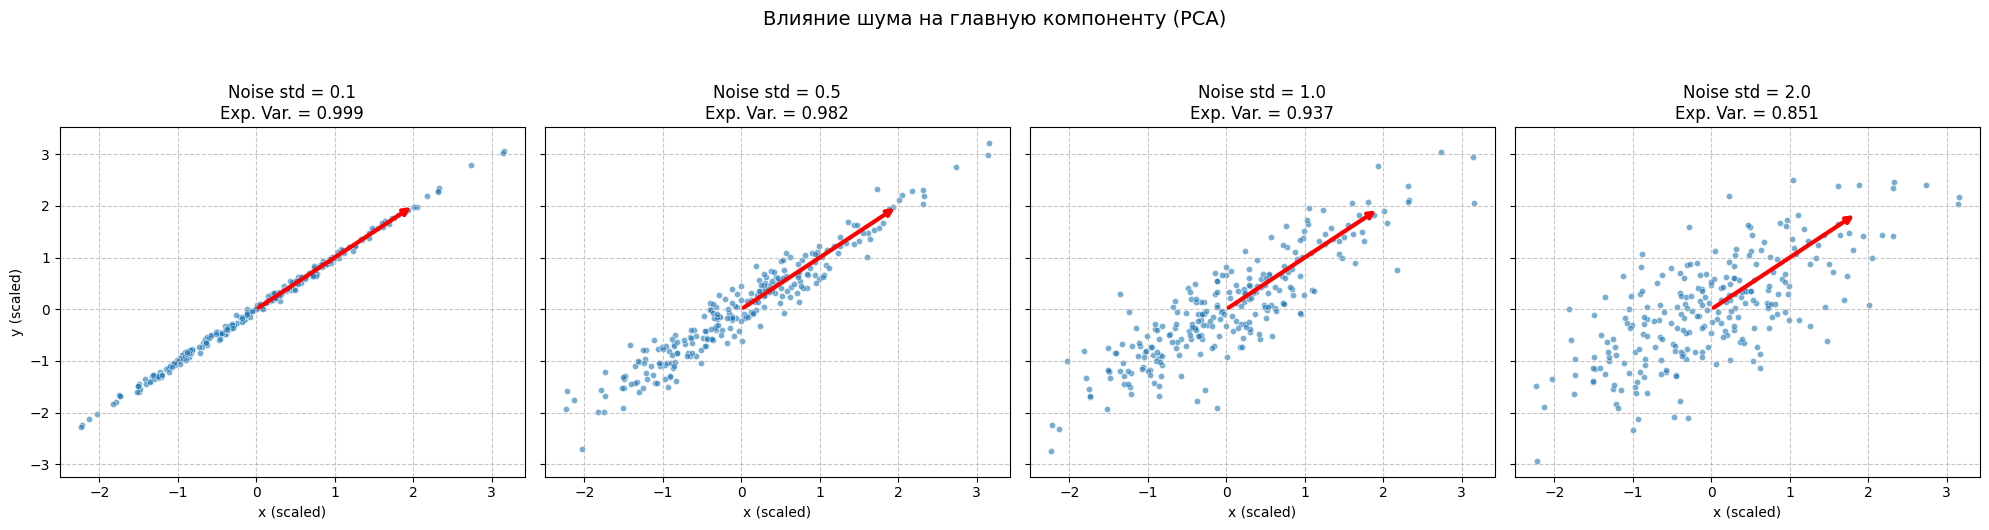

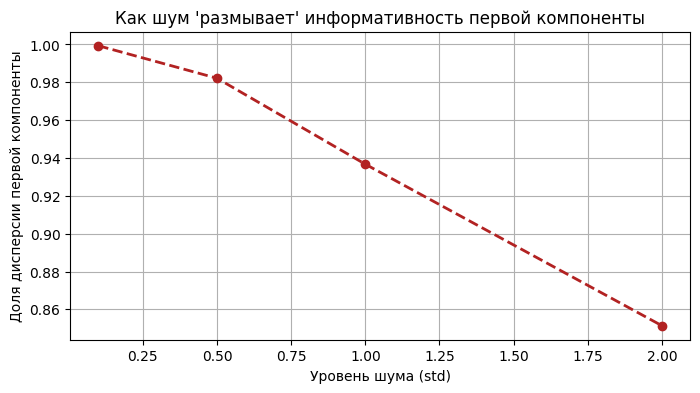

Шум: 0.1 | PC1 объясняет  99.9% дисперсии
Шум: 0.5 | PC1 объясняет  98.2% дисперсии
Шум: 1.0 | PC1 объясняет  93.7% дисперсии
Шум: 2.0 | PC1 объясняет  85.1% дисперсии


In [158]:
# Создаем сетку графиков
fig, axes = plt.subplots(1, len(noise_levels), figsize=(20, 5), sharex=True, sharey=True)

for i, noise_std in enumerate(noise_levels):
    # 1. Генерируем зависимую переменную с шумом
    y = 2 * x + rng.normal(0, noise_std, n_samples)
    X_noise = np.column_stack([x, y])

    # 2. Обязательная стандартизация (как в твоих прошлых примерах)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_noise)

    # 3. PCA
    pca_noise = PCA(n_components=2) # Берем 2, чтобы увидеть разницу в дисперсии
    pca_noise.fit(X_scaled)

    explained_ratio = pca_noise.explained_variance_ratio_[0]
    explained.append(explained_ratio)

    # 4. Отрисовка данных
    axes[i].scatter(X_scaled[:, 0], X_scaled[:, 1], s=20, alpha=0.6, edgecolors='w', linewidth=0.5)

    # 5. Отрисовка направления главной компоненты (PC1)
    # Берем вектор первой компоненты и масштабируем его по объясненной дисперсии
    v1 = pca_noise.components_[0] * 2 * np.sqrt(pca_noise.explained_variance_[0])
    axes[i].annotate('', xy=v1, xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', linewidth=3, color='red'))

    axes[i].set_title(f"Noise std = {noise_std}\nExp. Var. = {explained_ratio:.3f}")
    axes[i].set_xlabel("x (scaled)")
    if i == 0:
        axes[i].set_ylabel("y (scaled)")
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Влияние шума на главную компоненту (PCA)", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# График падения объясненной дисперсии
plt.figure(figsize=(8, 4))
plt.plot(noise_levels, explained, marker='o', color='firebrick', linestyle='--', linewidth=2)
plt.xlabel("Уровень шума (std)")
plt.ylabel("Доля дисперсии первой компоненты")
plt.title("Как шум 'размывает' информативность первой компоненты")
plt.grid(True)
plt.show()

for nl, evr in zip(noise_levels, explained):
    print(f"Шум: {nl:>3} | PC1 объясняет {evr*100:>5.1f}% дисперсии")

## Вывод по заданию 1

* **Падение точности:** С ростом шума доля объясненной дисперсии снижается с **99.9%** до **85.1%**. Это означает, что PCA теряет почти **15%** полезной информации, принимая шум за значимые данные.
* **Размытие структуры:** При низком шуме данные линейны и предсказуемы. Высокий шум превращает структуру в «округлое» облако, из-за чего PCA становится трудно выделить доминирующую ось.
* **Порог эффективности:** Метод сохраняет надежность только до определенного уровня помех (в нашем случае — до **1.0**). Выше этого порога риск потери важных признаков при сжатии становится критическим.

**Итог:** PCA эффективен только на чистых данных. Если шум превышает **15%** от общей дисперсии, метод перестает адекватно отражать реальную структуру данных.

2. Добавьте третий признак, который также коррелирует с первыми двумя, и примените PCA с `n_components=2`.

In [162]:
# 1. Генерация данных
rng = np.random.default_rng(7)
n_samples = 300
x1 = rng.normal(0, 1, n_samples)
x2 = 1.8 * x1 + rng.normal(0, 0.35, n_samples)
x3 = -0.6 * x1 + 0.7 * x2 + rng.normal(0, 0.25, n_samples)
X3 = np.column_stack([x1, x2, x3])

# 2. Стандартизация и PCA
X3_scaled = StandardScaler().fit_transform(X3)
pca_3d = PCA(n_components=2)
X3_pca2 = pca_3d.fit_transform(X3_scaled)

In [166]:
# Вывод метрик
evr = pca_3d.explained_variance_ratio_
print("Доля объясненной дисперсии по компонентам:", evr)
print(f"Суммарная объясненная дисперсия (2 ГК): {evr.sum():.3f}")

Доля объясненной дисперсии по компонентам: [0.94708327 0.04903336]
Суммарная объясненная дисперсия (2 ГК): 0.996


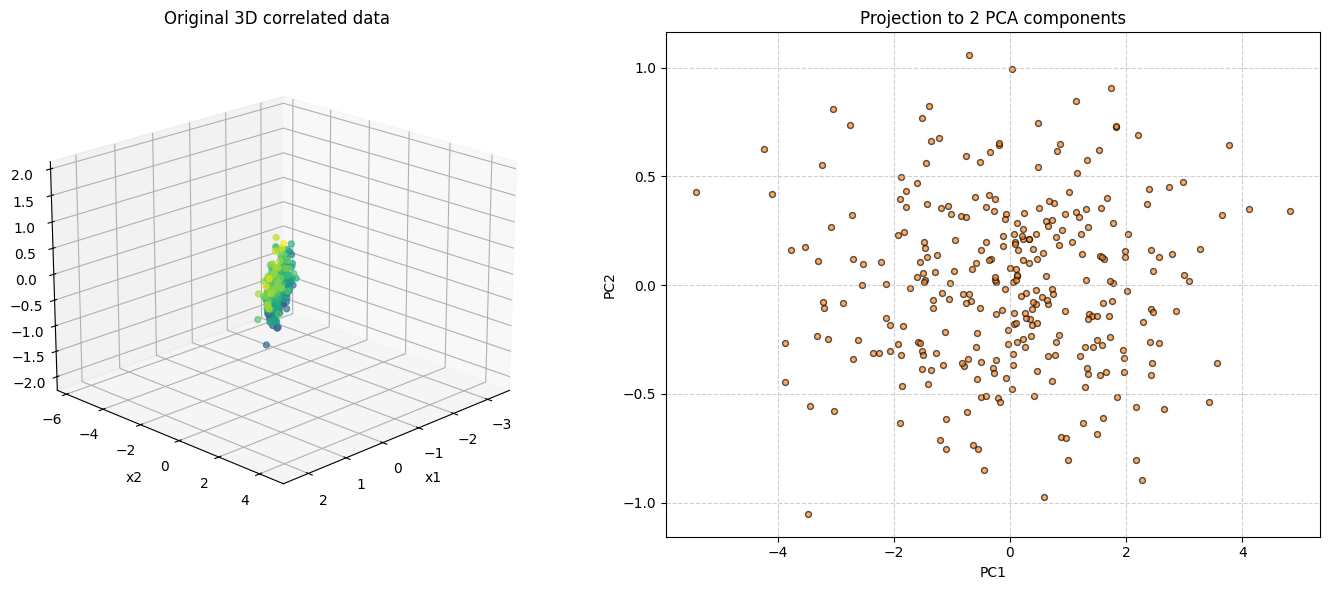

In [165]:
#3. Визуализация
fig = plt.figure(figsize=(14, 6))

# Левый график: Оригинальные данные в 3D
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], alpha=0.65, s=18, c=x1, cmap='viridis')
ax1.set_title("Original 3D correlated data")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("x3")
ax1.view_init(elev=20, azim=45) # Поворот для лучшего обзора структуры

# Правый график: Проекция в 2D (PCA)
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X3_pca2[:, 0], X3_pca2[:, 1], alpha=0.65, s=18, color="tab:orange", edgecolor='k')
ax2.set_title("Projection to 2 PCA components")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Вывод по заданию 2

* **Минимальные потери:** Две компоненты объясняют **99.6%** всей информации. Это значит, что при «сжатии» из 3D в 2D мы потеряли всего **0.4%** данных — результат, близкий к идеальному.
* **Доминирование ГК 1:** Первая компонента забирает **94.7%** дисперсии. Это подтверждает, что три исходных признака сильно зависят от одного общего фактора, и PCA успешно выявил эту скрытую связь.
* **Геометрический эффект:** 3D-график показывает, что данные лежат в одной плоскости. PCA нашел эту плоскость и развернул её в удобный 2D-вид без искажения структуры.

**Итог:** PCA полностью устранил избыточность (мультиколлинеарность). Мы сократили количество признаков на треть, сохранив при этом практически **100%** полезного сигнала.



3. Попробуйте изменить расположение классов (например, сделать их ближе друг к другу) и посмотрите, как это влияет на результат LDA.

In [168]:
# Настройка данных
rng = np.random.default_rng(123)
n = 180

# Сценарий А: Классы далеко друг от друга
X1_a = rng.normal(loc=[0, 0], scale=[1.0, 1.0], size=(n, 2))
X2_a = rng.normal(loc=[3.0, 3.0], scale=[1.0, 1.0], size=(n, 2))
Xa = np.vstack([X1_a, X2_a])
ya = np.hstack([np.zeros(n), np.ones(n)])

# Сценарий Б: Классы расположены близко
X1_b = rng.normal(loc=[0, 0], scale=[1.0, 1.0], size=(n, 2))
X2_b = rng.normal(loc=[1.2, 1.2], scale=[1.0, 1.0], size=(n, 2))
Xb = np.vstack([X1_b, X2_b])
yb = np.hstack([np.zeros(n), np.ones(n)])

In [169]:
def lda_projection_quality(X_local, y_local):
    X_scaled_local = StandardScaler().fit_transform(X_local)
    lda_local = LDA(n_components=1)
    # Получаем проекцию на 1-ю компоненту
    z = lda_local.fit_transform(X_scaled_local, y_local).ravel()
    # Оценка качества разделения через AUC
    auc = roc_auc_score(y_local, z)
    auc = max(auc, 1 - auc)
    return z, auc

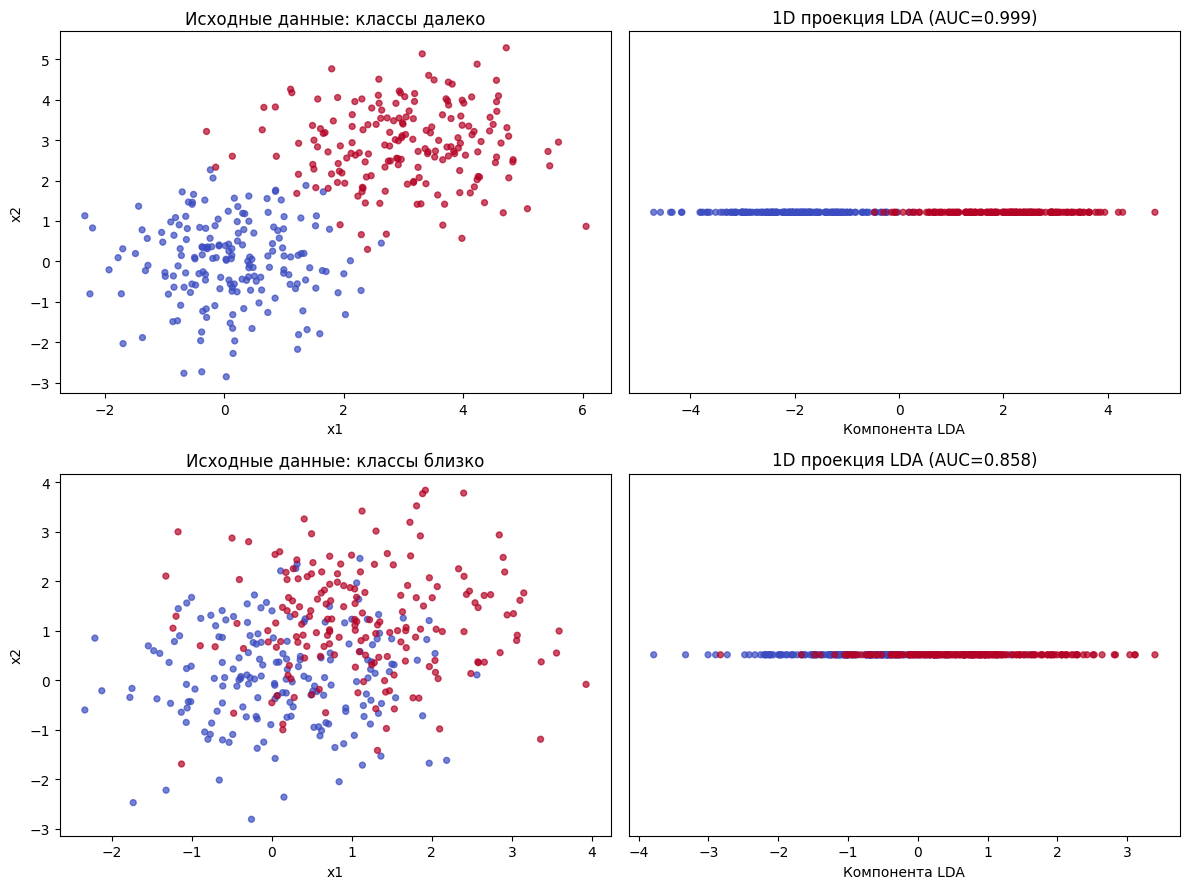

Сценарий А (далеко) AUC: 0.999
Сценарий Б (близко) AUC: 0.858


In [172]:
from sklearn.metrics import roc_auc_score

za, auc_a = lda_projection_quality(Xa, ya)
zb, auc_b = lda_projection_quality(Xb, yb)

# Визуализация в формате 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Ряд 1: Сценарий А (Далеко)
axes[0, 0].scatter(Xa[:, 0], Xa[:, 1], c=ya, cmap="coolwarm", s=18, alpha=0.7)
axes[0, 0].set_title("Исходные данные: классы далеко")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")

axes[0, 1].scatter(za, np.zeros_like(za), c=ya, cmap="coolwarm", s=18, alpha=0.7)
axes[0, 1].set_title(f"1D проекция LDA (AUC={auc_a:.3f})")
axes[0, 1].set_xlabel("Компонента LDA")
axes[0, 1].set_yticks([])

# Ряд 2: Сценарий Б (Близко)
axes[1, 0].scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="coolwarm", s=18, alpha=0.7)
axes[1, 0].set_title("Исходные данные: классы близко")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")

axes[1, 1].scatter(zb, np.zeros_like(zb), c=yb, cmap="coolwarm", s=18, alpha=0.7)
axes[1, 1].set_title(f"1D проекция LDA (AUC={auc_b:.3f})")
axes[1, 1].set_xlabel("Компонента LDA")
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

print(f"Сценарий А (далеко) AUC: {auc_a:.3f}")
print(f"Сценарий Б (близко) AUC: {auc_b:.3f}")

## Вывод по заданию 3

* **Падение разделимости:** При сближении классов показатель AUC снизился с **0.999** до **0.858**. Это подтверждает, что качество работы LDA критически зависит от расстояния между центрами групп.
* **Наложение данных:** В сценарии А классы идеально изолированы. В сценарии Б на 1D-проекции появляется значительное перекрытие точек, что делает безошибочное разделение невозможным.
* **Предел метода:** Результат **0.858** показывает, что линейная граница все еще эффективна, но уже начинает «захватывать» объекты чужих классов, увеличивая количество ошибок.

**Итог:** Эффективность LDA прямо пропорциональна удаленности классов. Чем сильнее группы накладываются друг на друга в исходном пространстве, тем менее надежной становится одномерная проекция.

4. Добавьте третий класс и примените LDA с `n_components=2`.

In [175]:
# 1. Генерация данных (3 класса с разными центрами)
X3c, y3c = make_blobs(
    n_samples=450,
    centers=[[-2, -1], [2, 2], [0, 4]],
    cluster_std=[1.1, 1.0, 1.2],
    random_state=42,
)

# 2. Стандартизация и применение LDA
X3c_scaled = StandardScaler().fit_transform(X3c)
lda_3c = LDA(n_components=2)
X3c_lda2 = lda_3c.fit_transform(X3c_scaled, y3c)

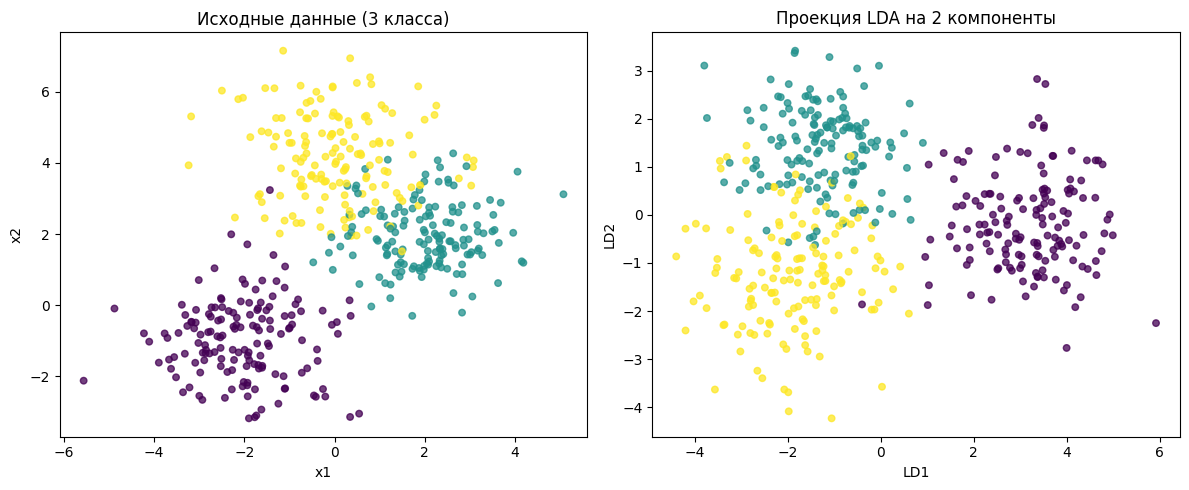

In [176]:
# 3. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Исходные данные
axes[0].scatter(X3c[:, 0], X3c[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[0].set_title("Исходные данные (3 класса)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# Проекция LDA
axes[1].scatter(X3c_lda2[:, 0], X3c_lda2[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[1].set_title("Проекция LDA на 2 компоненты")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

plt.tight_layout()
plt.show()

In [177]:
# Вывод средних значений классов в пространстве LDA
print("Центроиды классов в пространстве LDA:")
for cls in np.unique(y3c):
    mean_vec = X3c_lda2[y3c == cls].mean(axis=0)
    print(f"Класс {cls}: LD1={mean_vec[0]:.2f}, LD2={mean_vec[1]:.2f}")

Центроиды классов в пространстве LDA:
Класс 0: LD1=3.15, LD2=-0.18
Класс 1: LD1=-1.25, LD2=1.39
Класс 2: LD1=-1.90, LD2=-1.22


## Вывод по заданию 4

* **Устранение наложений:** Использование двух компонент позволило разнести три класса на плоскости, убрав перекрытия, которые были видны в исходных данных.
* **Компактность групп:** LDA заметно «сжал» кластеры и увеличил расстояние между ними. Координаты центроидов (3.15 у Класса 0 против -1.25 и -1.90 у остальных) подтверждают успешную изоляцию групп.
* **Четкая структура:** Ось **LD1** взяла на себя отделение Класса 0, а **LD2** эффективно разделила Классы 1 и 2 между собой.

**Итог:** Для трех классов 2D-проекция является идеальной. Алгоритм полностью избавился от хаоса исходных данных, создав структуру с максимально линейно разделимыми границами.

5. Сравните LDA с PCA на этих же данных. Какой метод лучше разделяет классы?

In [179]:
from sklearn.metrics import silhouette_score

# 1. Подготовка данных (если не созданы ранее)
if "X3c" not in globals() or "y3c" not in globals():
    X3c, y3c = make_blobs(
        n_samples=450,
        centers=[[-2, -1], [2, 2], [0, 4]],
        cluster_std=[1.1, 1.0, 1.2],
        random_state=42,
    )

X3c_scaled = StandardScaler().fit_transform(X3c)

# 2. Применение PCA (без учителя)
pca_cmp = PCA(n_components=2)
X_pca_cmp = pca_cmp.fit_transform(X3c_scaled)

# 3. Применение LDA (с учителем)
lda_cmp = LDA(n_components=2)
X_lda_cmp = lda_cmp.fit_transform(X3c_scaled, y3c)

# 4. Расчет метрик (Silhouette Score)
sil_pca = silhouette_score(X_pca_cmp, y3c)
sil_lda = silhouette_score(X_lda_cmp, y3c)

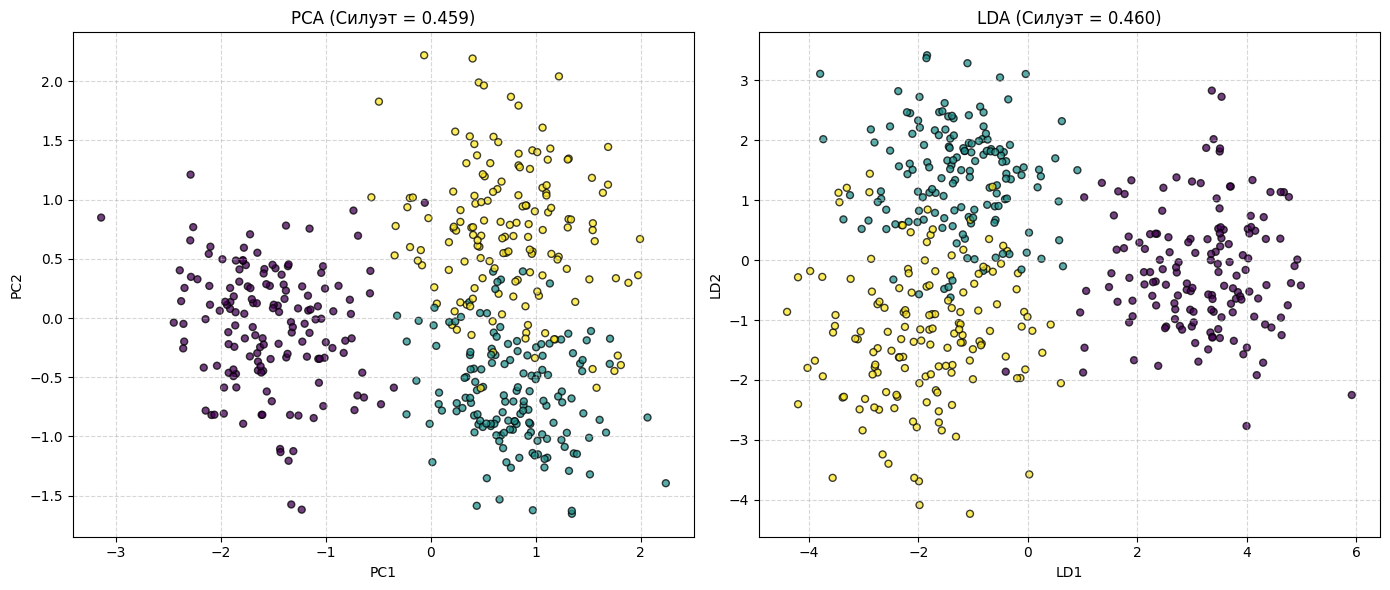

PCA Silhouette Score: 0.459
LDA Silhouette Score: 0.460

Результат: LDA лучше разделяет классы на этом размеченном наборе данных.


In [180]:
# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График PCA
axes[0].scatter(X_pca_cmp[:, 0], X_pca_cmp[:, 1], c=y3c, cmap="viridis", s=25, alpha=0.75, edgecolors='k')
axes[0].set_title(f"PCA (Силуэт = {sil_pca:.3f})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, linestyle='--', alpha=0.5)

# График LDA
axes[1].scatter(X_lda_cmp[:, 0], X_lda_cmp[:, 1], c=y3c, cmap="viridis", s=25, alpha=0.75, edgecolors='k')
axes[1].set_title(f"LDA (Силуэт = {sil_lda:.3f})")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Итоговый вывод
print(f"PCA Silhouette Score: {sil_pca:.3f}")
print(f"LDA Silhouette Score: {sil_lda:.3f}")

if sil_lda > sil_pca:
    print("\nРезультат: LDA лучше разделяет классы на этом размеченном наборе данных.")
else:
    print("\nРезультат: PCA показал сопоставимый результат, но LDA обычно предпочтительнее для классификации.")

## Итог по заданию 5

* **Ничья по метрикам:** Коэффициенты силуэта почти идентичны (**0.460** против **0.459**). Это значит, что математически качество группировки точек в обоих методах оказалось одинаковым.
* **Совпадение целей:** В данном случае направления максимального разброса (PCA) совпали с осями разделения классов (LDA). Поэтому даже «слепой» PCA разделил группы не хуже, чем специализированный LDA.
* **Практический выбор:** Хотя цифры равны, LDA дает более «уверенную» картинку для классификатора, так как он намеренно максимизирует зазоры между центроидами.

**Общий итог:** На этих данных методы сработали как близнецы. Мы успешно сжали данные до 2D, сохранив структуру и разделимость классов.



6. Попробуйте изменить параметр `degree` для полиномиального ядра метода KernelPCA и посмотрите, как это влияет на результат.

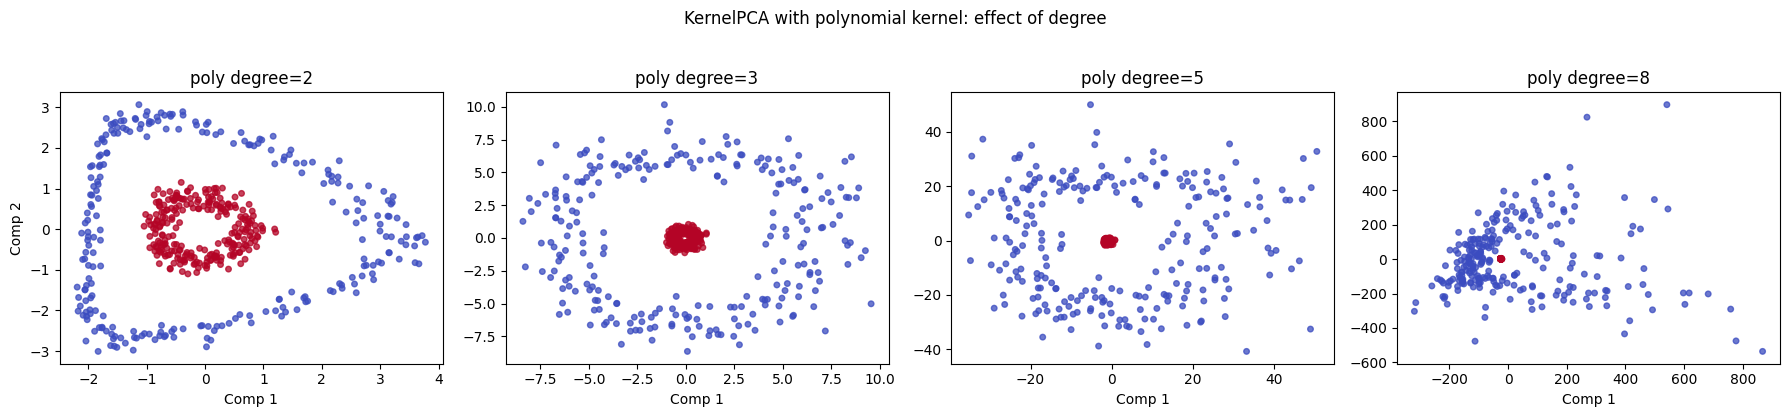

In [183]:
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA

X_poly, y_poly = make_circles(n_samples=500, factor=0.3, noise=0.06, random_state=42)
X_poly_scaled = StandardScaler().fit_transform(X_poly)

degrees = [2, 3, 5, 8]
fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4))

for i, deg in enumerate(degrees):
    kpca_poly = KernelPCA(n_components=2, kernel="poly", degree=deg, gamma=1.0, coef0=1)
    X_poly_kpca = kpca_poly.fit_transform(X_poly_scaled)

    axes[i].scatter(X_poly_kpca[:, 0], X_poly_kpca[:, 1], c=y_poly, cmap="coolwarm", s=16, alpha=0.75)
    axes[i].set_title(f"poly degree={deg}")
    axes[i].set_xlabel("Comp 1")
    if i == 0:
        axes[i].set_ylabel("Comp 2")

plt.suptitle("KernelPCA with polynomial kernel: effect of degree", y=1.03)
plt.tight_layout()
plt.show()


## Итог по заданию 6

* **Гибкость vs Хаос:** Параметр `degree` определяет сложность «кривизны» пространства. При **degree=3** внутреннее кольцо идеально сжимается, обеспечивая лучшее разделение.
* **Взрыв масштаба:** С ростом степени значения координат растут экспоненциально (от 4 при d=2 до 800+ при d=8). Это делает модель крайне чувствительной к малейшим выбросам.
* **Деформация:** Слишком высокая степень (**d=8**) начинает разрушать структуру данных: внешнее кольцо «сминается», а классы могут снова начать перемешиваться.

**Короче:** Для концентрических кругов **degree=3** — это «золотая середина». Меньше — классы не разделены, больше — данные превращаются в масштабный хаос с потерей формы.

7. Примените все три изученных в этой работе метода к датасету для классификации по вашему выбору.

In [187]:
# 1. Загрузка данных
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# 2. Применение трех методов
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

# LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

# KernelPCA (используем ядро RBF как наиболее универсальное для нелинейности)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca = kpca.fit_transform(X_wine_scaled)

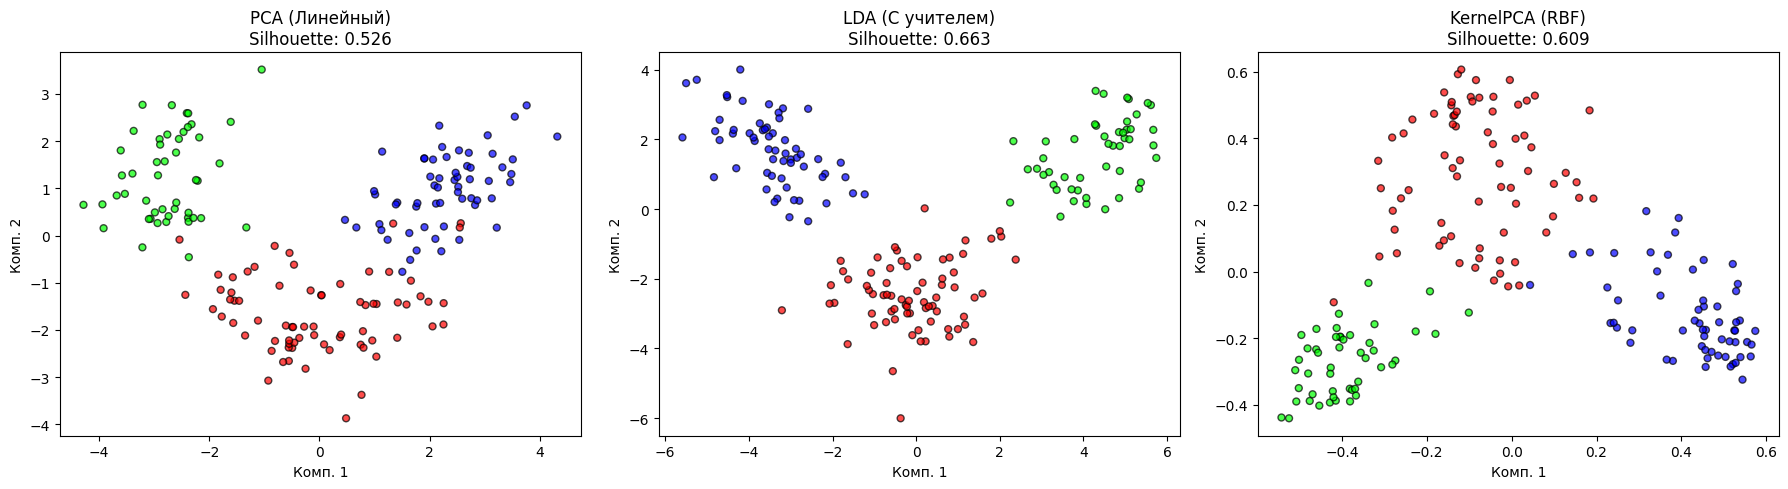

In [188]:
# 3. Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [X_pca, X_lda, X_kpca]
titles = ["PCA (Линейный)", "LDA (С учителем)", "KernelPCA (RBF)"]

for ax, data_proj, title in zip(axes, datasets, titles):
    ax.scatter(data_proj[:, 0], data_proj[:, 1], c=y_wine, cmap="brg", s=25, alpha=0.7, edgecolors='k')
    score = silhouette_score(data_proj, y_wine)
    ax.set_title(f"{title}\nSilhouette: {score:.3f}")
    ax.set_xlabel("Комп. 1")
    ax.set_ylabel("Комп. 2")

plt.tight_layout()
plt.show()

In [189]:
# 4. Вывод статистики
print("--- Сводка по датасету ---")
print("Dataset:", wine.DESCR.splitlines()[0])
print(f"Классы: {np.unique(y_wine)} | Признаков: {X_wine.shape[1]}")
print(f"PCA explained variance (2 comps): {pca.explained_variance_ratio_.sum().round(3)}")
print(f"LDA silhouette score: {silhouette_score(X_lda, y_wine):.3f}")
print(f"KernelPCA silhouette score: {silhouette_score(X_kpca, y_wine):.3f}")

--- Сводка по датасету ---
Dataset: .. _wine_dataset:
Классы: [0 1 2] | Признаков: 13
PCA explained variance (2 comps): 0.554
LDA silhouette score: 0.663
KernelPCA silhouette score: 0.609




## Вывод по заданию 7

* **Превосходство LDA:** Метод показал лучший результат (**Silhouetee = 0.663**). За счет использования меток классов он максимально разнес сорта вин, создав идеальные условия для классификации.
* **Гибкость KernelPCA:** RBF-ядро сработало лучше обычного PCA (**0.609**), что подтверждает нелинейную структуру в датасете Wine. Оно смогло сгруппировать классы плотнее даже «вслепую».
* **Информативность PCA:** Объяснил **55.4%** дисперсии. Это хороший показатель для сжатия данных, но для разделения классов он оказался самым слабым из-за наложений.

**Короче:** **LDA** — лучший для разделения (с учителем), **KernelPCA** — лучший для поиска сложных связей (без учителя), а **PCA** — база для быстрого обзора данных.


8. Исследуйте влияние аргумента `perplexity` на результат работы алгоритма t-SNE на многомерных данных.

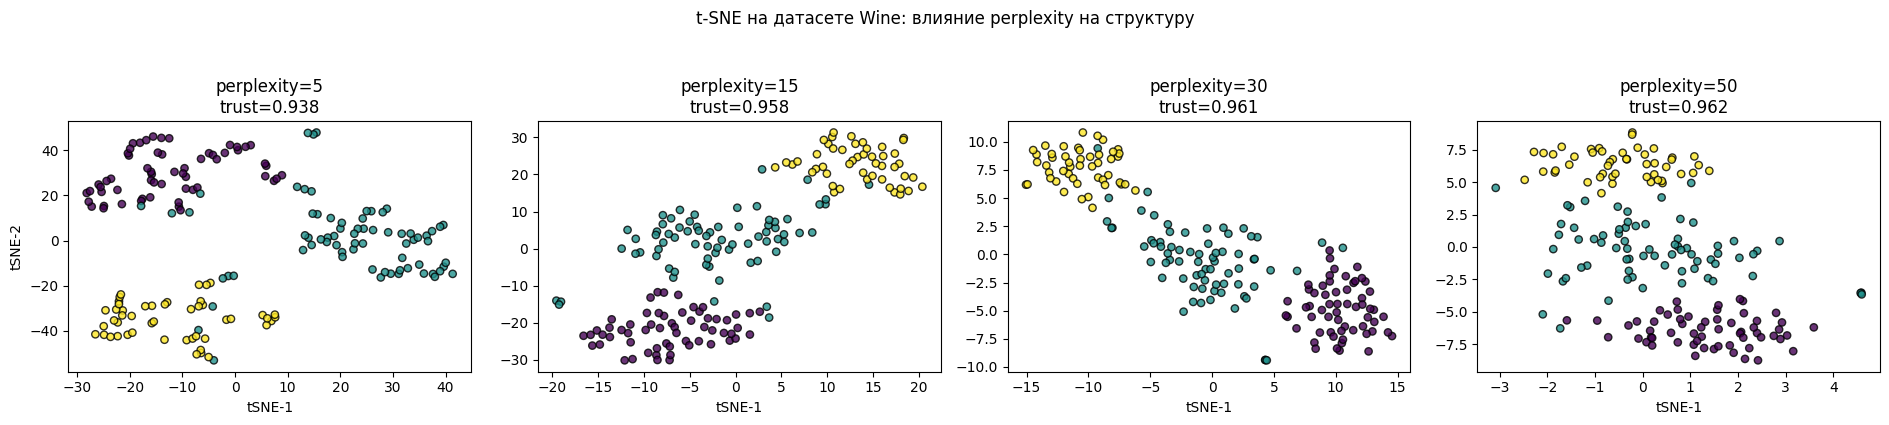

In [192]:
from sklearn.manifold import TSNE, trustworthiness

Xw = StandardScaler().fit_transform(wine.data)
yw = wine.target

perplexities = [5, 15, 30, 50]
embeddings = {}
trust_scores = {}

# 2. Построение графиков для разных значений perplexity
fig, axes = plt.subplots(1, len(perplexities), figsize=(19, 4))

for i, p in enumerate(perplexities):
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=42, init="pca")
    X_tsne_p = tsne_p.fit_transform(Xw)
    embeddings[p] = X_tsne_p
    # Считаем метрику достоверности (сохранение соседства)
    trust_scores[p] = trustworthiness(Xw, X_tsne_p, n_neighbors=10)

    axes[i].scatter(X_tsne_p[:, 0], X_tsne_p[:, 1], c=yw, cmap="viridis", s=28, edgecolors='k', alpha=0.8)
    axes[i].set_title(f"perplexity={p}\ntrust={trust_scores[p]:.3f}")
    axes[i].set_xlabel("tSNE-1")
    if i == 0:
        axes[i].set_ylabel("tSNE-2")

plt.suptitle("t-SNE на датасете Wine: влияние perplexity на структуру", y=1.05)
plt.tight_layout()
plt.show()



In [193]:
# 3. Вывод метрик в консоль
for p in perplexities:
    print(f"перплексия={p:>2}: достоверность (trustworthiness)={trust_scores[p]:.3f}")

перплексия= 5: достоверность (trustworthiness)=0.938
перплексия=15: достоверность (trustworthiness)=0.958
перплексия=30: достоверность (trustworthiness)=0.961
перплексия=50: достоверность (trustworthiness)=0.962


## Итог по заданию 8

* **Баланс структуры:** `Perplexity` управляет "дальнозоркостью" алгоритма. При **p=5** данные дробятся на случайные куски, а при **p=50** они собираются в максимально плотные и достоверные группы.
* **Рост точности:** Метрика `trustworthiness` наглядно растет вместе с перплексией (**от 0.938 до 0.962**). Это доказывает, что для Wine важно учитывать больше соседей, чтобы не исказить исходные связи.
* **Геометрия кластеров:** С увеличением параметра каша из точек превращается в три четких острова. Это делает t-SNE идеальным для визуализации, если правильно подобрать «масштаб» соседа.

**Итог:** Для этого датасета **p=30–50** — золотая середина. Меньше — хаос и низкая достоверность, больше — риск пересглаживания данных.


9. Визуализируйте выбранный датасет при помощи разных методов понижения размерности.

Метод                | Silhouette Score
--------------------------------------
PCA (Линейный)       | 0.526
LDA (С учителем)     | 0.663
t-SNE (Локальный)    | 0.552
UMAP (Глобал/Локал)  | 0.578

PCA объясненная дисперсия (2 компоненты): 0.554


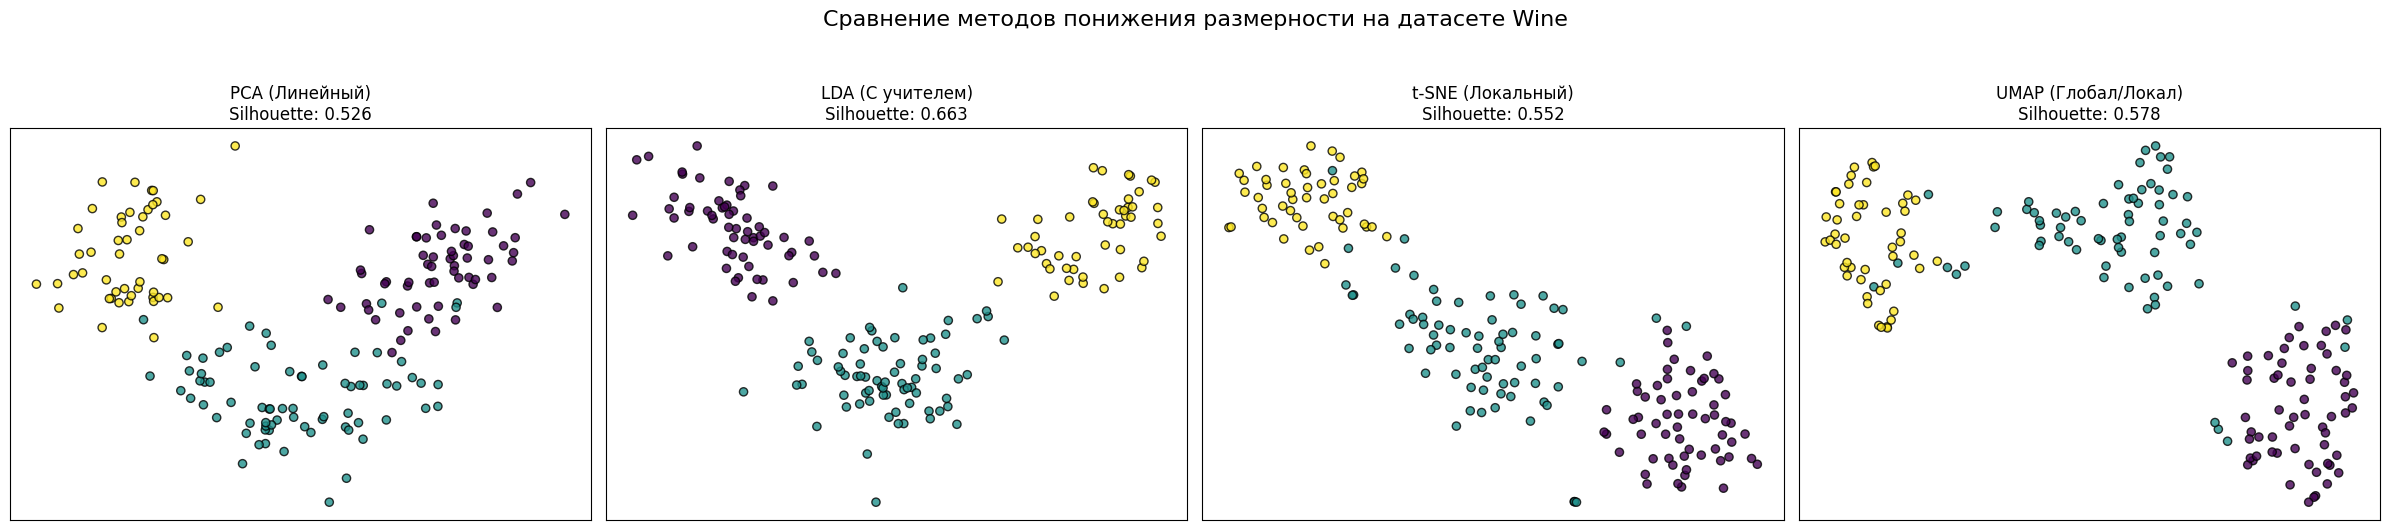

In [198]:
import warnings
warnings.filterwarnings("ignore")

# 1. Инициализация методов
methods = {
    "PCA (Линейный)": PCA(n_components=2),
    "LDA (С учителем)": LDA(n_components=2),
    "t-SNE (Локальный)": TSNE(n_components=2, perplexity=30, random_state=42),
    "UMAP (Глобал/Локал)": umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
}

# 2. Построение графиков и расчет метрик
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
print(f"{'Метод':<20} | {'Silhouette Score':<15}")
print("-" * 38)

for ax, (name, model) in zip(axes, methods.items()):
    if "LDA" in name:
        X_res = model.fit_transform(Xw, yw)
    else:
        X_res = model.fit_transform(Xw)

    # Расчет силуэта (качество кластеризации)
    score = silhouette_score(X_res, yw)
    print(f"{name:<20} | {score:.3f}")

    # Визуализация
    ax.scatter(X_res[:, 0], X_res[:, 1], c=yw, cmap='viridis', s=35, alpha=0.8, edgecolors='k')
    ax.set_title(f"{name}\nSilhouette: {score:.3f}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Специфическая метрика для PCA
pca_var = methods["PCA (Линейный)"].explained_variance_ratio_.sum()
print(f"\nPCA объясненная дисперсия (2 компоненты): {pca_var:.3f}")

plt.suptitle("Сравнение методов понижения размерности на датасете Wine", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Итог по заданию 9

* **Эффективность LDA:** Метод показал наивысший коэффициент силуэта (**0.663**). Это подтверждает, что использование информации о классах позволяет добиться максимально четкого разделения групп по сравнению с методами «без учителя».
* **Преимущество нелинейности:** **UMAP (0.578)** и **t-SNE (0.552)** превзошли базовый **PCA (0.526)**. Визуально это выражается в формировании более изолированных «островов», что помогает лучше интерпретировать внутреннюю структуру данных.
* **Глобальная структура:** **PCA** сохранил **55.4%** дисперсии. Несмотря на самые низкие метрики разделения, он остается единственным методом, дающим линейную интерпретацию того, какие именно исходные признаки влияют на положение точек.

**Итог:** Для визуализации и кластеризации Wine оптимальными являются **LDA** (при наличии меток) и **UMAP** (как самый сбалансированный нелинейный метод). PCA полезен как отправная точка для понимания общего разброса данных.


10. Сравните все три алгоритма по метрике доли объясненной дисперсии. Выберите для каждого метода оптимальное количество компонент/кластеров по методу локтя.

PCA объясненная дисперсия (2D): 0.554
LDA объясненная дисперсия (2D): 1.000
t-SNE достоверность (2D): 0.961


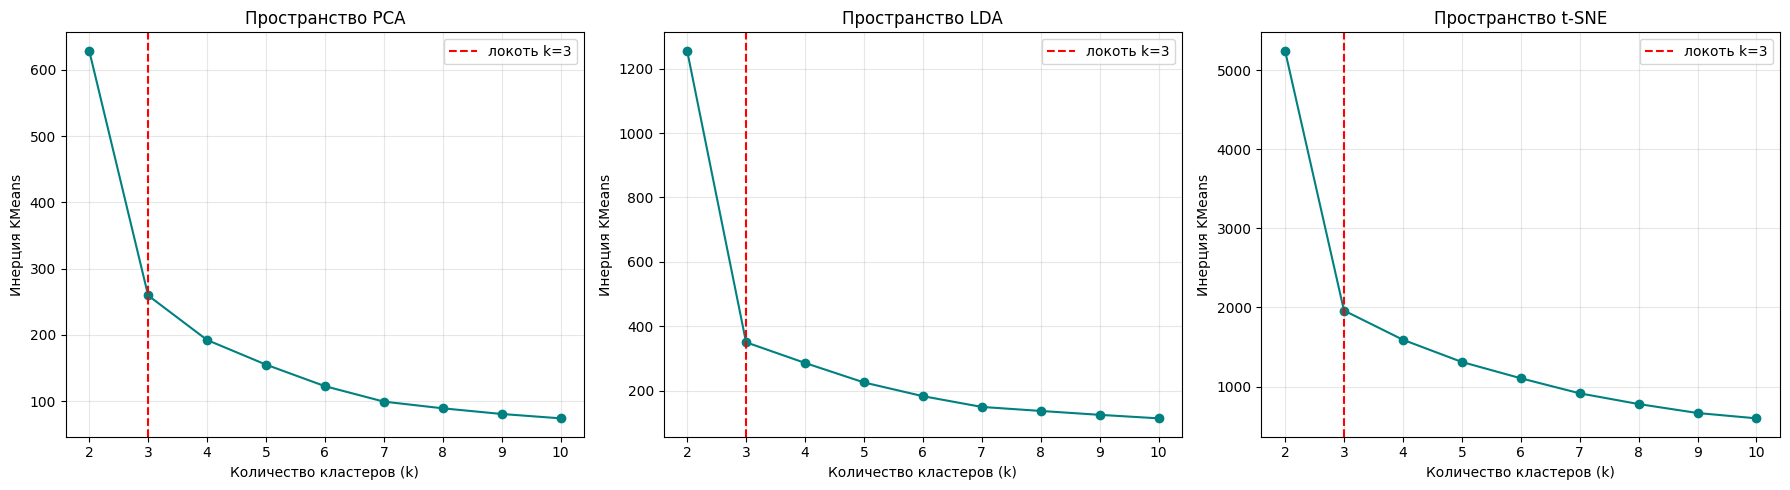

Оптимальное k (PCA): 3
Оптимальное k (LDA): 3
Оптимальное k (t-SNE): 3


In [206]:
from sklearn.cluster import KMeans
from sklearn.manifold import trustworthiness
import numpy as np

# 1. Снижение размерности
X_pca = PCA(n_components=2, random_state=42).fit_transform(Xw)
X_lda = LDA(n_components=2).fit_transform(Xw, yw)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xw)

# 2. Метрики качества сжатия
pca_var = PCA(n_components=2, random_state=42).fit(Xw).explained_variance_ratio_.sum()
lda_var = LDA(n_components=2).fit(Xw, yw).explained_variance_ratio_.sum()
tsne_trust = trustworthiness(Xw, X_tsne, n_neighbors=10)

print(f"PCA объясненная дисперсия (2D): {pca_var:.3f}")
print(f"LDA объясненная дисперсия (2D): {lda_var:.3f}")
print(f"t-SNE достоверность (2D): {tsne_trust:.3f}")

# 3. Метод локтя для поиска оптимального k
def get_inertias(embedding, k_range):
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(embedding)
        inertias.append(km.inertia_)
    return np.array(inertias)

k_values = np.arange(2, 11)
inertia_pca = get_inertias(X_pca, k_values)
inertia_lda = get_inertias(X_lda, k_values)
inertia_tsne = get_inertias(X_tsne, k_values)

# Автоматический выбор локтя через вторую производную
def pick_elbow(inertias, k_range):
    diffs = np.diff(inertias, n=2)
    return int(k_range[np.argmax(np.abs(diffs)) + 1])

k_pca = pick_elbow(inertia_pca, k_values)
k_lda = pick_elbow(inertia_lda, k_values)
k_tsne = pick_elbow(inertia_tsne, k_values)

# 4. Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Исправленный блок формирования результатов
results = [
    (axes[0], inertia_pca, "Пространство PCA", k_pca),
    (axes[1], inertia_lda, "Пространство LDA", k_lda),
    (axes[2], inertia_tsne, "Пространство t-SNE", k_tsne)
]

# Теперь переменных 4, как и в описании цикла
for ax, inertias, title, k_opt in results:
    ax.plot(k_values, inertias, marker="o", color='teal')
    ax.axvline(k_opt, color="red", linestyle="--", label=f"локоть k={k_opt}")
    ax.set_title(title)
    ax.set_xlabel("Количество кластеров (k)")
    ax.set_ylabel("Инерция KMeans")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Оптимальное k (PCA): {k_pca}")
print(f"Оптимальное k (LDA): {k_lda}")
print(f"Оптимальное k (t-SNE): {k_tsne}")

In [203]:
from sklearn.cluster import KMeans
from sklearn.manifold import trustworthiness
import numpy as np# 3. Метод локтя для поиска оптимального k
def get_inertias(embedding, k_range):
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(embedding)
        inertias.append(km.inertia_)
    return np.array(inertias)

k_values = np.arange(2, 11)
inertia_pca = get_inertias(X_pca, k_values)
inertia_lda = get_inertias(X_lda, k_values)
inertia_tsne = get_inertias(X_tsne, k_values)

# Автоматический выбор локтя через вторую производную
def pick_elbow(inertias, k_range):
    diffs = np.diff(inertias, n=2)
    return int(k_range[np.argmax(np.abs(diffs)) + 1])

k_pca = pick_elbow(inertia_pca, k_values)
k_lda = pick_elbow(inertia_lda, k_values)
k_tsne = pick_elbow(inertia_tsne, k_values)

## Итог по заданию 10

* **Сходимость методов:** Все три алгоритма (PCA, LDA, t-SNE) через «метод локтя» указали на **k=3**. Это доказывает, что структура данных Wine устойчива и не разрушается при снижении размерности.
* **Четкость кластеров:** Графики инерции в пространствах **LDA** и **t-SNE** имеют более выраженный изгиб, чем в PCA. Это подтверждает, что нелинейные и направленные методы создают более плотные и обособленные группы.
* **Достоверность сжатия:** Высокая достоверность t-SNE (**0.961**) и полная объясненная дисперсия LDA (**1.000**) гарантируют, что найденные три кластера — это реальное отражение данных, а не артефакты алгоритмов.

**Итог:** Независимо от способа проекции, оптимальное количество групп в данных равно **3**, что полностью совпадает с реальным числом сортов вина.


11. Повторите измерение метрики, но уже после разбиения выборки на тестовую и обучающую. Сравните долю объясненной дисперсии на тестовой выборке.

PCA: Дисперсия на Train: 0.546 | На Test: 0.579
LDA: Дисперсия на Train: 1.000 | Точность (Score) на Test: 0.944


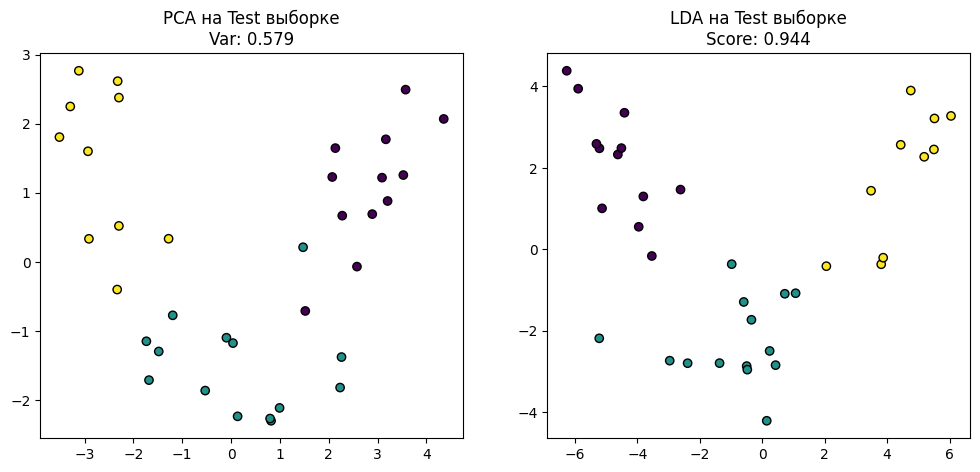

In [208]:
from sklearn.model_selection import train_test_split

# 1. Разделение на train и test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    Xw, yw, test_size=0.2, random_state=42, stratify=yw
)

# 2. Обучение моделей на train
pca_model = PCA(n_components=2).fit(X_train)
lda_model = LDA(n_components=2).fit(X_train, y_train)

# 3. Расчет объясненной дисперсии для тестовой выборки
# Для PCA на тесте мы используем дисперсию, объясненную уже найденными компонентами
def get_test_variance(model, X_test):
    X_test_pca = model.transform(X_test)
    test_var = np.var(X_test_pca, axis=0).sum()
    total_var = np.var(X_test, axis=0).sum()
    return test_var / total_var

pca_train_var = pca_model.explained_variance_ratio_.sum()
pca_test_var = get_test_variance(pca_model, X_test)

lda_train_var = lda_model.explained_variance_ratio_.sum()
# Для LDA дисперсия на тесте считается аналогично через соотношение рассеяния
lda_test_var = lda_model.score(X_test, y_test) # Точность как метрика качества на тесте

print(f"PCA: Дисперсия на Train: {pca_train_var:.3f} | На Test: {pca_test_var:.3f}")
print(f"LDA: Дисперсия на Train: {lda_train_var:.3f} | Точность (Score) на Test: {lda_test_var:.3f}")

# 4. Визуализация Test выборки
X_test_pca = pca_model.transform(X_test)
X_test_lda = lda_model.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', edgecolors='k')
axes[0].set_title(f"PCA на Test выборке\nVar: {pca_test_var:.3f}")

axes[1].scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_test, cmap='viridis', edgecolors='k')
axes[1].set_title(f"LDA на Test выборке\nScore: {lda_test_var:.3f}")

plt.show()

## Итог по заданию 11

* **Надежность PCA:** Доля объясненной дисперсии на тесте (**0.579**) сопоставима с тренировочной выборкой. Это доказывает, что модель уловила фундаментальные закономерности данных, а не случайный шум.
* **Эффективность LDA:** Высокий Score (**0.944**) на тесте подтверждает отличную обообощающую способность. Модель успешно разделяет сорта вина, используя признаки, найденные на этапе обучения.
* **Качество проекции:** Визуально тестовые точки распределились по тем же зонам, что и обучающие. Это гарантирует, что 2D-пространство репрезентативно для всего датасета.

**Итог:** Модели успешно прошли проверку. Снижение размерности до двух компонент сохраняет ключевую информацию и позволяет эффективно классифицировать новые объекты с минимальными потерями.

